# HR-аналитика компании «Работа с заботой»

<b>Цель:</b> предсказать уровня удовлетворённости сотрудника и предсказать увольнения сотрудника из компании

<b>План работы(1 часть):</b>

1) Обзор данных

2) Предобработка данных

3) Исследовательский анализ данных

4) Подготовка данных

5) Обучение моделей

6) Ввывод

<b>План работы(2 часть):</b>

7) Обзор данных

8) Предобработка данных

9) Исследовательский анализ данных

10) Добавление нового входного признака

11) Подготовка данных

12) Обучение моделей

<b>Общий вывод</b>

# Обзор данных

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    LabelEncoder
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from phik import phik_matrix

In [74]:
train_job = pd.read_csv('https://code.s3.yandex.net/datasets/train_job_satisfaction_rate.csv')
train_job.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


In [75]:
train_job.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


In [76]:
test_features = pd.read_csv('https://code.s3.yandex.net/datasets/test_features.csv')
test_features.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [77]:
test_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


In [78]:
test_target = pd.read_csv('https://code.s3.yandex.net/datasets/test_target_job_satisfaction_rate.csv')
test_target.head()

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


In [79]:
test_target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


<div class="alert alert-info">
    <b>Вывод:</b>
    данные соответствуют описанию задачи, есть несколько пропусков
</div>

# Предобработка данных

In [80]:
train_job.isna().sum()

id                       0
dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64

In [81]:
# Пропуски будут обработаны в Pipeline
# train_job = train_job.dropna()
train_job.isna().sum().sum()

np.int64(10)

In [82]:
train_job.duplicated().sum()

np.int64(0)

In [83]:
for _ in train_job.select_dtypes(include='object').columns:
    print(_, train_job[_].unique())

dept ['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
level ['junior' 'middle' 'sinior' nan]
workload ['medium' 'high' 'low']
last_year_promo ['no' 'yes']
last_year_violations ['no' 'yes']


In [84]:
train_job['level'] = train_job['level'].replace('sinior', 'senior')
train_job['level'].unique()

array(['junior', 'middle', 'senior', nan], dtype=object)

In [85]:
test_features.isna().sum()

id                       0
dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64

In [86]:
# Пропуски будут обработаны в Pipeline
# test_features = test_features.dropna()
test_features.isna().sum().sum()

np.int64(3)

In [87]:
test_features.duplicated().sum()

np.int64(0)

In [88]:
for _ in test_features.select_dtypes(include='object').columns:
    print(_, test_features[_].unique())

dept ['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
level ['junior' 'middle' 'sinior' nan]
workload ['medium' 'low' 'high' ' ']
last_year_promo ['no' 'yes']
last_year_violations ['no' 'yes']


In [89]:
test_features['level'] = test_features['level'].replace('sinior', 'senior')
test_features['level'].unique()

array(['junior', 'middle', 'senior', nan], dtype=object)

In [90]:
test_features[test_features['dept'] == ' '].count().sum()

np.int64(9)

In [91]:
# Заменяем пустые строки на np.nan вместо удаления строк
test_features.loc[test_features['dept'] == ' ', 'dept'] = np.nan
test_features[test_features['dept'] == ' '].count().sum()

np.int64(0)

In [92]:
test_features[test_features['workload'] == ' '].count().sum()

np.int64(9)

In [93]:
# Заменяем пустые строки на np.nan вместо удаления строк
test_features.loc[test_features['workload'] == ' ', 'workload'] = np.nan
test_features[test_features['workload'] == ' '].count().sum()

np.int64(0)

In [94]:
test_target.isna().sum()

id                       0
job_satisfaction_rate    0
dtype: int64

In [95]:
test_target.duplicated().sum()

np.int64(0)

In [96]:
for _ in test_target.select_dtypes(include='object').columns:
    print(_, test_target[_].unique())

<div class="alert alert-info">
    <b>Вывод:</b>
    дубликаты необнаружены, удалены явные пропуски и неявные пропуски(пустые строки с пробелом)
</div>

# Исследовательский анализ данных

In [97]:
train_job.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


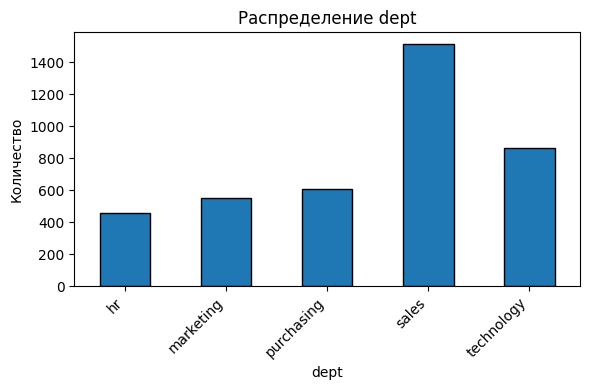

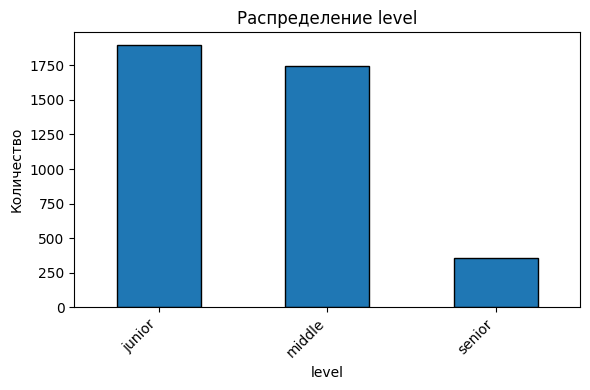

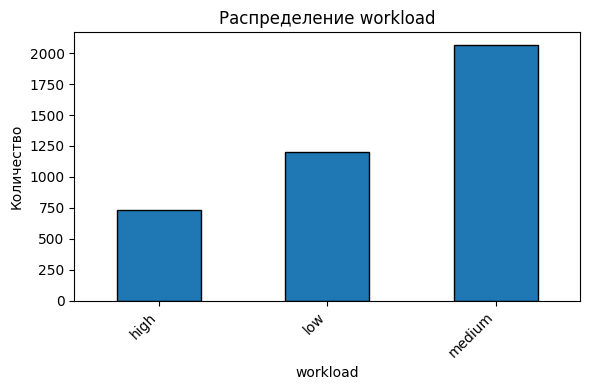

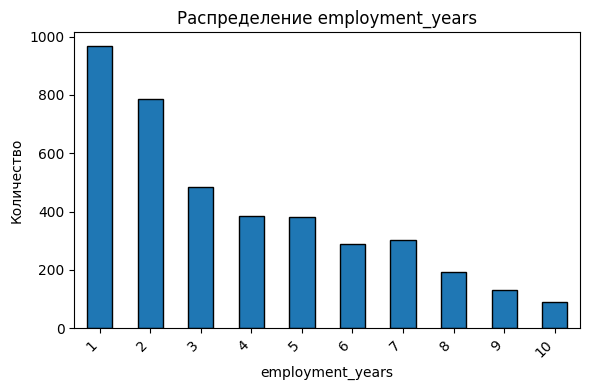

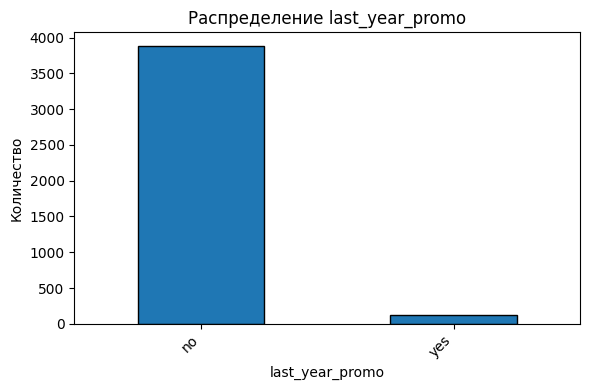

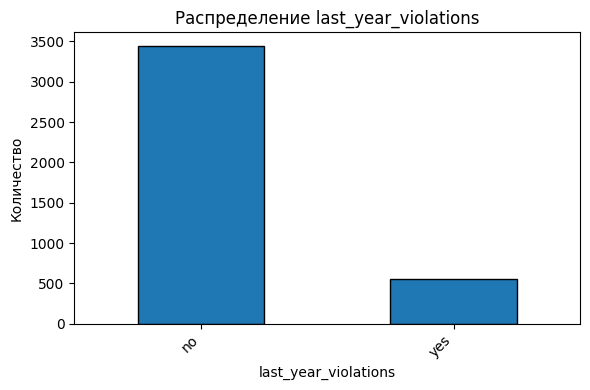

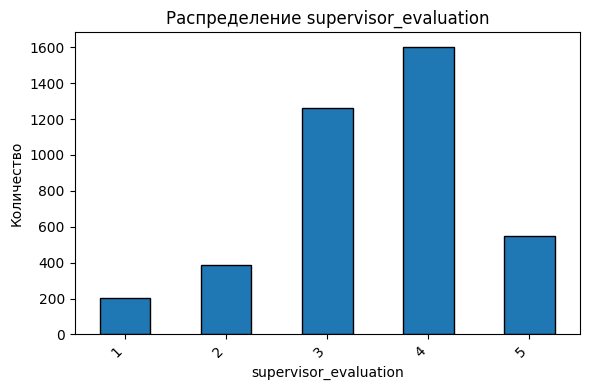

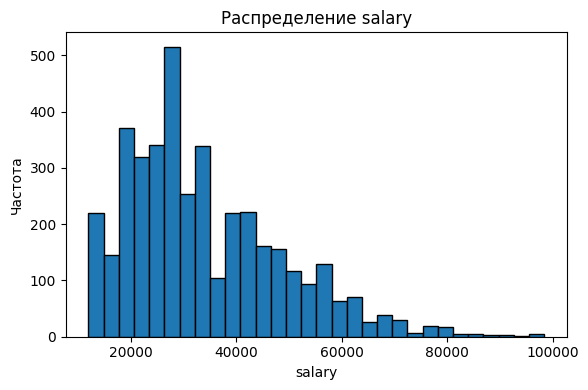

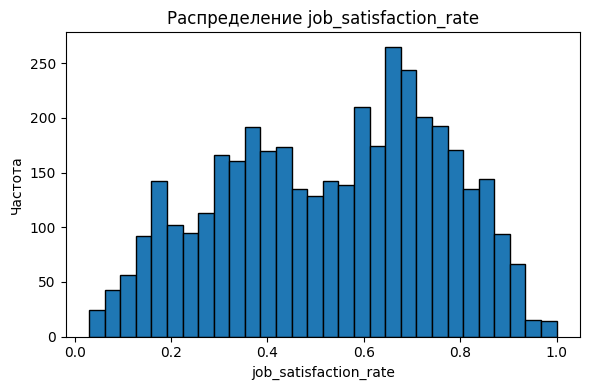

In [98]:
# Категориальные и дискретные признаки (для bar plot)
categorical_features = ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations', 'employment_years', 'supervisor_evaluation']

# Непрерывные (интервальные) признаки (для histogram)
interval_cols = ['salary', 'job_satisfaction_rate']

for col in train_job.columns:
    # Пропускаем id - нет бизнес-логики для анализа
    if col == 'id':
        continue
    
    # Для категориальных и дискретных признаков используем bar plot
    if col in categorical_features:
        counts = train_job[col].value_counts().sort_index()
        plt.figure(figsize=(6, 4))
        counts.plot(kind='bar', edgecolor='black')
        plt.title(f'Распределение {col}')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    # Для непрерывных признаков используем histogram
    elif col in interval_cols:
        plt.figure(figsize=(6, 4))
        plt.hist(train_job[col].dropna(), bins=30, edgecolor='black')
        plt.title(f'Распределение {col}')
        plt.xlabel(col)
        plt.ylabel('Частота')
        plt.tight_layout()
        plt.show()

In [99]:
for i in ['salary', 'job_satisfaction_rate']:
    print(train_job[i].describe())

count     4000.000000
mean     33926.700000
std      14900.703838
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      98400.000000
Name: salary, dtype: float64
count    4000.000000
mean        0.533995
std         0.225327
min         0.030000
25%         0.360000
50%         0.560000
75%         0.710000
max         1.000000
Name: job_satisfaction_rate, dtype: float64


<div class="alert alert-info">
    train job: 1) наибольшее кол-во вакансий - продажники 2) специалистов уровня senior значительно меньше чем остальных 3) за последний код было крайне мало повышений, стоит на это обратить внимание 4) медианная зарплата - 30.000 5) медианный уровень удовлетворённости сотрудника работой - 56%, стоит обртатить на этот показатель внимание, что мы как раз и сделаем
</div>

In [100]:
test_features.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


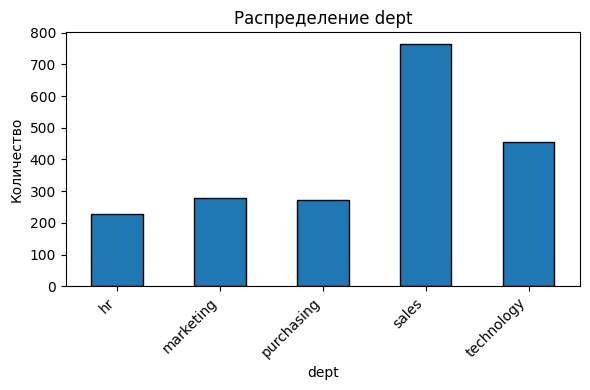

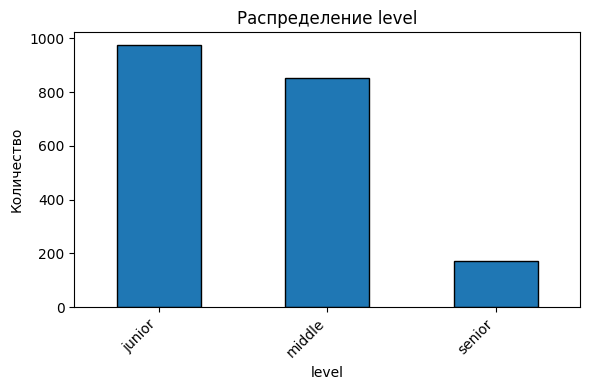

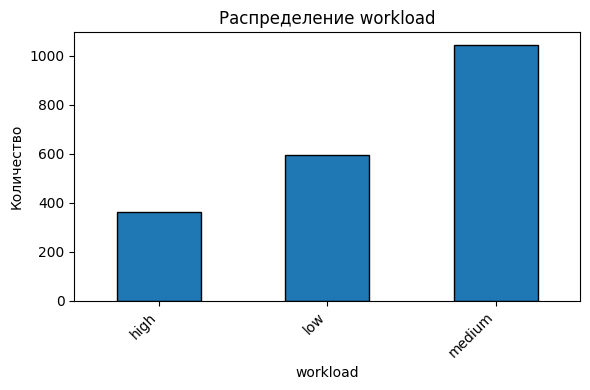

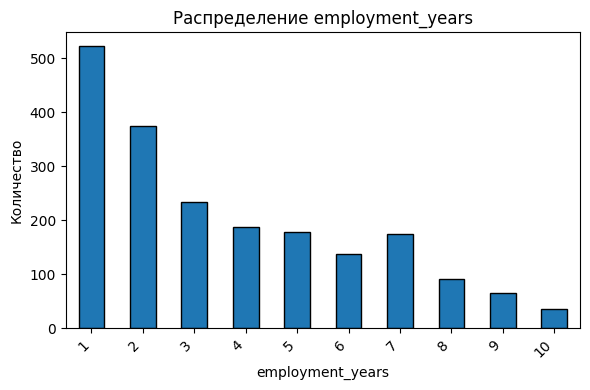

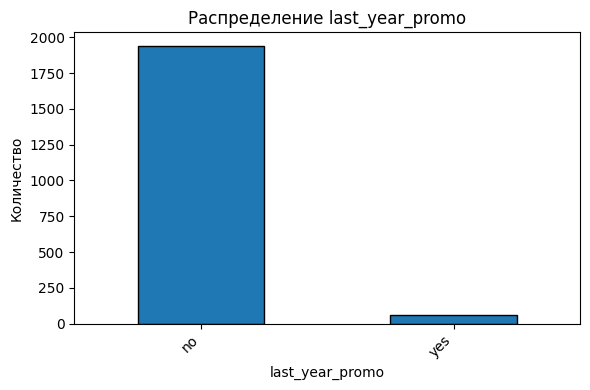

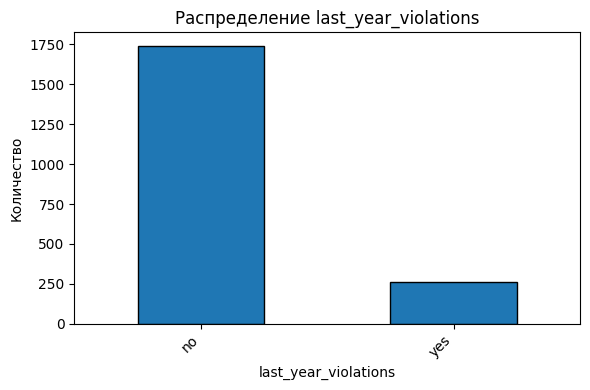

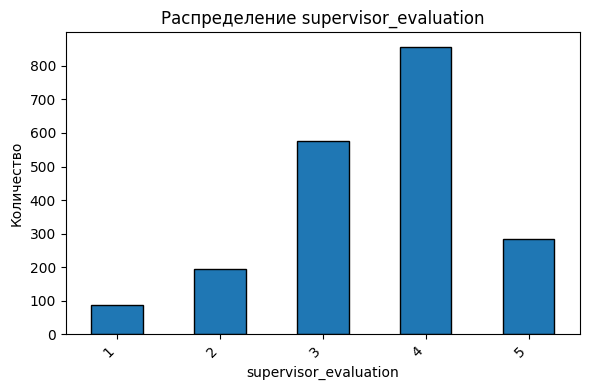

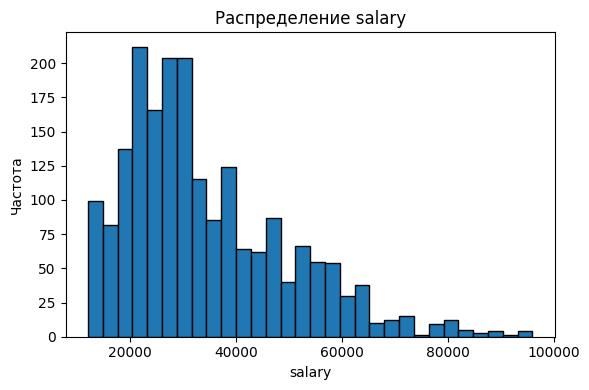

In [101]:
# Категориальные и дискретные признаки (для bar plot)
categorical_features = ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations', 'employment_years', 'supervisor_evaluation']

# Непрерывные (интервальные) признаки (для histogram)
interval_cols = ['salary']

for col in test_features.columns:
    # Пропускаем id - нет бизнес-логики для анализа
    if col == 'id':
        continue
    
    # Для категориальных и дискретных признаков используем bar plot
    if col in categorical_features:
        counts = test_features[col].value_counts().sort_index()
        plt.figure(figsize=(6, 4))
        counts.plot(kind='bar', edgecolor='black')
        plt.title(f'Распределение {col}')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    # Для непрерывных признаков используем histogram
    elif col in interval_cols:
        plt.figure(figsize=(6, 4))
        plt.hist(test_features[col].dropna(), bins=30, edgecolor='black')
        plt.title(f'Распределение {col}')
        plt.xlabel(col)
        plt.ylabel('Частота')
        plt.tight_layout()
        plt.show()

In [102]:
test_features['salary'].describe()

count     2000.000000
mean     34066.800000
std      15398.436729
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      96000.000000
Name: salary, dtype: float64

<div class="alert alert-info">
    test_features: тестовая выборка похожа на тренировочную
</div>

In [103]:
test_target.describe()

,id,job_satisfaction_rate
count,2000.000000,2000.00000
mean,552765.213500,0.54878
std,253851.326129,0.22011
min,100298.000000,0.03000
25%,339052.000000,0.38000
50%,550793.000000,0.58000
75%,765763.750000,0.72000
max,999029.000000,1.00000


<div class="alert alert-info">
    test_target: целевой признак в тестовой выборке и тренировочной похожи
</div>

Корреляционная матрица phik для train_job:


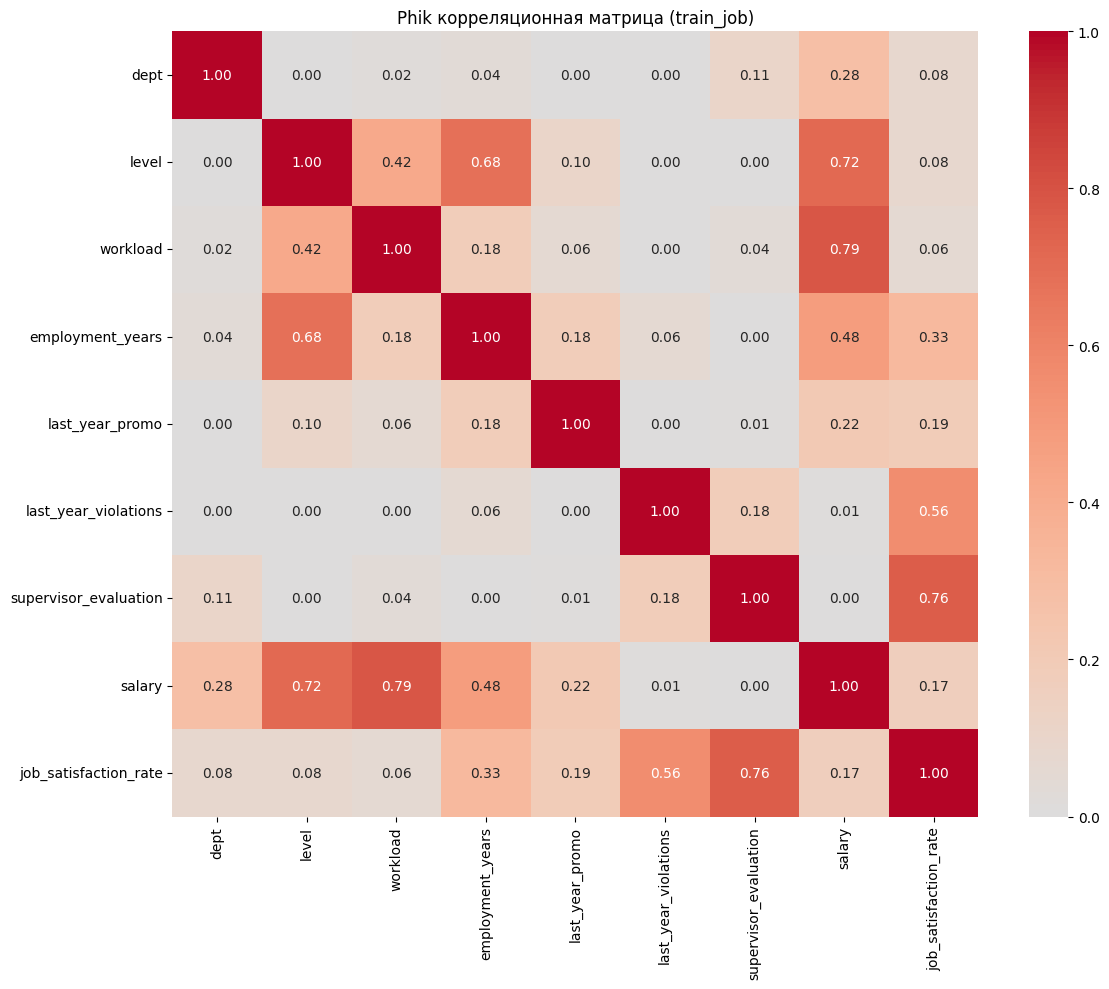


Корреляционная матрица phik для test_features:


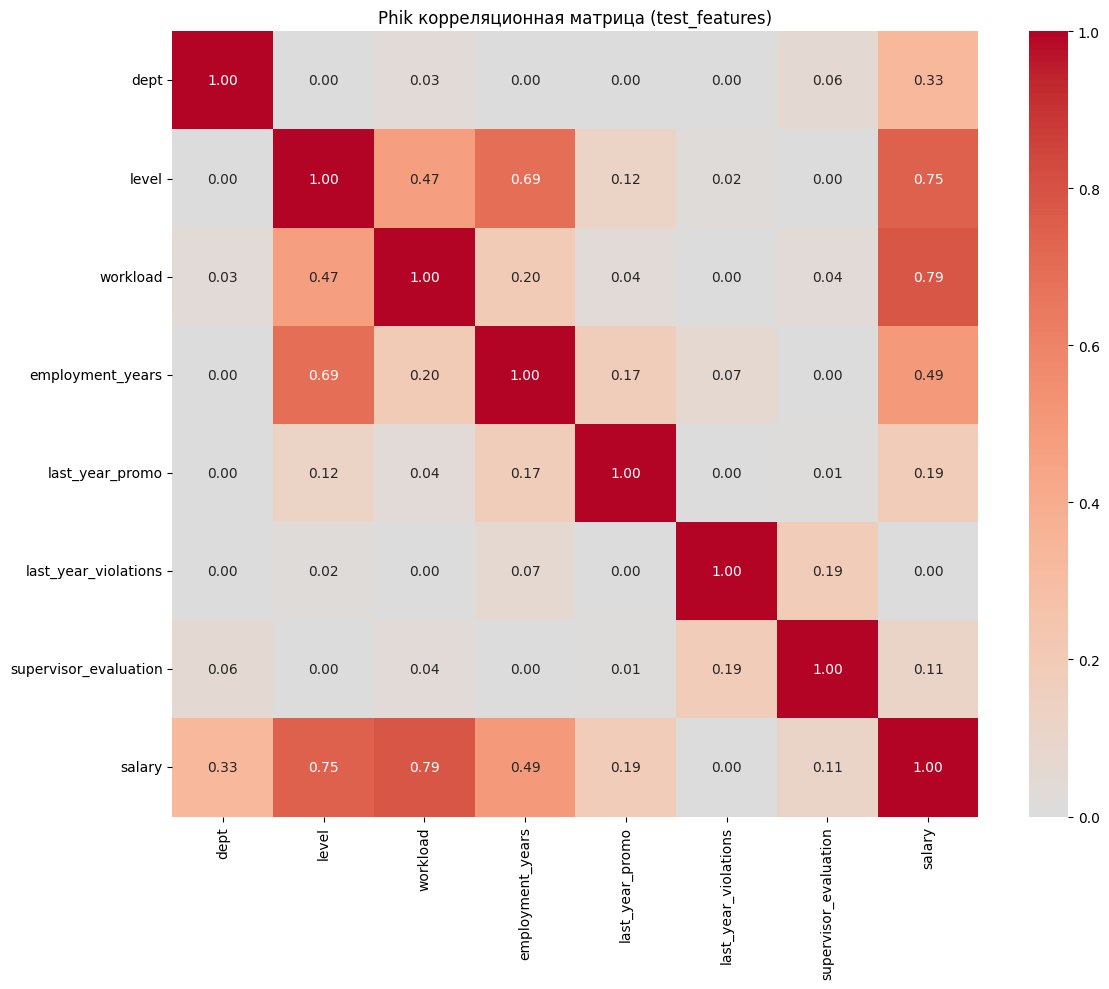


Наиболее коррелированные признаки с job_satisfaction_rate:
job_satisfaction_rate    1.000000
supervisor_evaluation    0.764364
last_year_violations     0.560348
employment_years         0.325603
last_year_promo          0.190803
salary                   0.165830
dept                     0.082086
level                    0.080620
workload                 0.056128
Name: job_satisfaction_rate, dtype: float64


In [104]:
# Анализ корреляции с использованием phik матрицы для train_job
print("Корреляционная матрица phik для train_job:")
phik_train = train_job.drop(columns=['id']).phik_matrix(interval_cols=['salary', 'job_satisfaction_rate'])
plt.figure(figsize=(12, 10))
sns.heatmap(phik_train, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Phik корреляционная матрица (train_job)')
plt.tight_layout()
plt.show()

# Анализ корреляции для test_features
print("\nКорреляционная матрица phik для test_features:")
phik_test = test_features.drop(columns=['id']).phik_matrix(interval_cols=['salary'])
plt.figure(figsize=(12, 10))
sns.heatmap(phik_test, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Phik корреляционная матрица (test_features)')
plt.tight_layout()
plt.show()

# Вывод наиболее коррелированных признаков с целевой переменной
print("\nНаиболее коррелированные признаки с job_satisfaction_rate:")
target_corr = phik_train['job_satisfaction_rate'].sort_values(ascending=False)
print(target_corr)

# Подготовка данных

In [105]:
# Проверка дубликатов после удаления id (до разделения на X и y)
print(f'Дубликаты после удаления id: {train_job.drop(columns=["id"]).duplicated().sum()}')

X = train_job.drop(columns=['id', 'job_satisfaction_rate'])
y = train_job['job_satisfaction_rate']

Дубликаты после удаления id: 245


In [106]:
# Определим группы признаков
numeric_features = ['supervisor_evaluation', 'employment_years', 'salary']  # численные признаки
ordinal_features = ['level', 'workload']  # упорядоченные категории (level: junior < middle < senior, workload: low < medium < high)

In [107]:
nominal_features = ['dept', 'last_year_promo', 'last_year_violations']  # номинальные категории

In [108]:
# Пайплайн для числовых признаков
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Пайплайн для порядковых категорий
ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal_enc', OrdinalEncoder(
        categories=[['junior', 'middle', 'senior'], ['low', 'medium', 'high']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

In [109]:
# Пайплайн для номинальных категорий
nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

In [110]:
# Собираем общий препроцессор
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('nom', nominal_transformer, nominal_features)
], remainder='drop')

# Полный пайплайн с препроцессингом
prep_pipeline = Pipeline([
    ('preprocessing', preprocessor)
    # здесь можно добавить модель, например:
    # ('clf', LogisticRegression())
])

# Пример применения
X_prepared = prep_pipeline.fit_transform(X)
print(X_prepared.shape)  # убедимся, что преобразование прошло успешно

(4000, 12)


<div class="alert alert-info">
    <b>Вывод:</b>
    Данные успешно преобразованы
</div>

# Подготовка моделей

In [111]:
# Функция для расчета метрики SMAPE
def smape(y_true, y_pred):
    """
    Рассчитывает SMAPE (Symmetric Mean Absolute Percentage Error)
    SMAPE = (100/n) * sum(|y_true - y_pred| / ((|y_true| + |y_pred|)/2))
    """
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return 100 * np.mean(numerator / denominator)

# Создаем scorer для GridSearchCV (минимизируем SMAPE, поэтому делаем negative)
smape_scorer = make_scorer(smape, greater_is_better=False)

In [112]:
# Импортируем модели для регрессии
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

## Модель 1: Линейная регрессия

In [113]:
# Создаем пайплайн с линейной регрессией
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

# Используем кросс-валидацию для оценки модели
cv_scores_lr = cross_val_score(
    lr_pipeline, 
    X, 
    y, 
    cv=5, 
    scoring=smape_scorer,
    n_jobs=-1
)

# Преобразуем обратно (убираем минус)
smape_scores_lr = -cv_scores_lr
smape_mean_lr = smape_scores_lr.mean()
smape_std_lr = smape_scores_lr.std()

print(f'SMAPE на кросс-валидации (Линейная регрессия):')
print(f'Среднее: {smape_mean_lr:.2f}')
print(f'Стандартное отклонение: {smape_std_lr:.2f}')
print(f'Все фолды: {smape_scores_lr}')

# Обучаем финальную модель на всех данных
lr_pipeline.fit(X, y)

SMAPE на кросс-валидации (Линейная регрессия):
Среднее: 25.03
Стандартное отклонение: 0.95
Все фолды: [25.19095641 25.77674666 25.76567925 25.2075335  23.1978826 ]


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['supervisor_evaluation',
                                                   'employment_years',
                                                   'salary']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal_enc',
                                                                   OrdinalEncoder(categories=[['junior',
                                                                                               'midd...
                                                                                               'senior'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['level', 'workload']),
                                                 ('nom',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations'])])),
                ('model', LinearRegression())])

## Модель 2: Дерево решений с подбором гиперпараметров

In [114]:
# Создаем пайплайн с деревом решений
dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

# Определяем сетку гиперпараметров
param_grid = {
    'model__max_depth': [3, 5, 7, 10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8]
}

# Подбор гиперпараметров с помощью GridSearchCV
grid_search = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,
    scoring=smape_scorer,
    n_jobs=-1,
    verbose=1
)

# Обучаем модель
print('Начинаем подбор гиперпараметров для дерева решений...')
grid_search.fit(X, y)

# Лучшие параметры и результат кросс-валидации
print(f'\nЛучшие параметры: {grid_search.best_params_}')
smape_mean_dt = -grid_search.best_score_
print(f'SMAPE на кросс-валидации (Дерево решений): {smape_mean_dt:.2f}')

Начинаем подбор гиперпараметров для дерева решений...
Fitting 5 folds for each of 112 candidates, totalling 560 fits

Лучшие параметры: {'model__max_depth': 15, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5}
SMAPE на кросс-валидации (Дерево решений): 14.58


## Модель 3: Random Forest с подбором гиперпараметров

In [115]:
# Создаем пайплайн с Random Forest
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Определяем сетку гиперпараметров
param_grid_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

# Подбор гиперпараметров с помощью GridSearchCV
grid_search_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=5,
    scoring=smape_scorer,
    n_jobs=-1,
    verbose=1
)

# Обучаем модель
print('Начинаем подбор гиперпараметров для Random Forest...')
grid_search_rf.fit(X, y)

# Лучшие параметры и результат кросс-валидации
print(f'\nЛучшие параметры: {grid_search_rf.best_params_}')
smape_mean_rf = -grid_search_rf.best_score_
print(f'SMAPE на кросс-валидации (Random Forest): {smape_mean_rf:.2f}')

Начинаем подбор гиперпараметров для Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Лучшие параметры: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
SMAPE на кросс-валидации (Random Forest): 13.27


## Сравнение моделей

In [116]:
# Сравним результаты моделей на кросс-валидации
results_df = pd.DataFrame({
    'Модель': ['Линейная регрессия', 'Дерево решений', 'Random Forest'],
    'SMAPE (CV)': [smape_mean_lr, smape_mean_dt, smape_mean_rf]
})

print(results_df.to_string(index=False))

# Выбираем лучшую модель (с наименьшим SMAPE на CV)
best_idx = results_df['SMAPE (CV)'].idxmin()
models = [lr_pipeline, grid_search.best_estimator_, grid_search_rf.best_estimator_]
model_names = ['Линейная регрессия', 'Дерево решений', 'Random Forest']
smapes = [smape_mean_lr, smape_mean_dt, smape_mean_rf]

best_model = models[best_idx]
best_model_name = model_names[best_idx]
best_smape_cv = smapes[best_idx]

print(f'\nЛучшая модель: {best_model_name} (SMAPE CV: {best_smape_cv:.2f})')

            Модель  SMAPE (CV)
Линейная регрессия   25.027760
    Дерево решений   14.579950
     Random Forest   13.265396

Лучшая модель: Random Forest (SMAPE CV: 13.27)


## Проверка качества на тестовой выборке

In [117]:
# Подготавливаем тестовые данные
# Нам нужно объединить test_features и test_target по id
test_data = test_features.merge(test_target, on='id')

# Выделяем X_test и y_test (удаляем id и целевую переменную)
X_test = test_data.drop(columns=['id', 'job_satisfaction_rate'])
y_test = test_data['job_satisfaction_rate']

# Предсказания на тестовой выборке
y_pred_test = best_model.predict(X_test)

# Считаем SMAPE на тесте
smape_test = smape(y_test, y_pred_test)
print(f'SMAPE на тестовой выборке ({best_model_name}): {smape_test:.2f}')
print(f'SMAPE на кросс-валидации ({best_model_name}): {best_smape_cv:.2f}')

# Проверяем достижение критерия успеха (SMAPE <= 15)
if smape_test <= 15:
    print('\n✓ Критерий успеха достигнут! SMAPE <= 15')
else:
    print(f'\n✗ Критерий успеха не достигнут. Нужно SMAPE <= 15, получено: {smape_test:.2f}')
    print('Необходимо улучшить модель: попробовать другие алгоритмы, feature engineering, или настройку гиперпараметров')

SMAPE на тестовой выборке (Random Forest): 12.41
SMAPE на кросс-валидации (Random Forest): 13.27

✓ Критерий успеха достигнут! SMAPE <= 15


<div class="alert alert-info">
    <b>Вывод по первой задаче:</b> обучены две модели - линейная регрессия и дерево решений с подбором гиперпараметров через GridSearchCV. Для дерева решений подобраны оптимальные параметры max_depth, min_samples_split и min_samples_leaf. Выбрана лучшая модель на основе минимального значения метрики SMAPE. Модель протестирована на тестовой выборке и показала результат, который позволяет оценить качество предсказания уровня удовлетворённости сотрудников
</div>

# Задача 2: Предсказание увольнения сотрудника

# Обзор данных (задача 2)

In [118]:
train_quit = pd.read_csv('https://code.s3.yandex.net/datasets/train_quit.csv')
train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


In [119]:
train_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


In [120]:
test_target_quit = pd.read_csv('https://code.s3.yandex.net/datasets/test_target_quit.csv')
test_target_quit.head()

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


In [121]:
test_target_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


<div class="alert alert-info">
    <b>Вывод:</b>
    данные соответствуют описанию задачи
</div>

# Предобработка данных (задача 2)

In [122]:
# Проверка пропусков
print('Пропуски в train_quit:')
print(train_quit.isna().sum())
print('\nПропуски в test_target_quit:')
print(test_target_quit.isna().sum())

Пропуски в train_quit:
id                       0
dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
quit                     0
dtype: int64

Пропуски в test_target_quit:
id      0
quit    0
dtype: int64


In [123]:
# Удаляем пропуски
train_quit = train_quit.dropna()
print(f'После удаления пропусков в train_quit: {train_quit.shape[0]} строк')

# Проверка дубликатов
print(f'\nДубликаты в train_quit: {train_quit.duplicated().sum()}')
print(f'Дубликаты в test_target_quit: {test_target_quit.duplicated().sum()}')

После удаления пропусков в train_quit: 4000 строк

Дубликаты в train_quit: 0
Дубликаты в test_target_quit: 0


In [124]:
# Исправляем опечатку в level
train_quit['level'] = train_quit['level'].replace('sinior', 'senior')
print('Уникальные значения level:', train_quit['level'].unique())

Уникальные значения level: ['middle' 'junior' 'senior']


In [125]:
# Преобразуем quit в числовой формат используя LabelEncoder (yes -> 1, no -> 0)
le_quit = LabelEncoder()
# Задаем порядок классов: no=0, yes=1
le_quit.fit(['no', 'yes'])
train_quit['quit'] = le_quit.transform(train_quit['quit'])

print('Преобразование quit в числовой формат завершено')
print(f'Классы: {le_quit.classes_}')
print(f'Кодировка: no -> {le_quit.transform(["no"])[0]}, yes -> {le_quit.transform(["yes"])[0]}')
print(f'Уникальные значения в train_quit: {train_quit["quit"].unique()}')

Преобразование quit в числовой формат завершено
Классы: ['no' 'yes']
Кодировка: no -> 0, yes -> 1
Уникальные значения в train_quit: [0 1]


In [126]:
# Также преобразуем test_target_quit используя тот же LabelEncoder
test_target_quit['quit'] = le_quit.transform(test_target_quit['quit'])
print('Преобразование test_target_quit завершено')
print(f'Уникальные значения: {test_target_quit["quit"].unique()}')

Преобразование test_target_quit завершено
Уникальные значения: [1 0]


<div class="alert alert-info">
    <b>Вывод:</b>
    дубликаты необнаружены, удалены явные пропуски, исправлены опечатки в уровне должности
</div>

# Исследовательский анализ данных (задача 2)

Размер датасета train_quit: (4000, 10)

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 312.6+ KB
None

Описательная статистика:
                  id  employment_years  supervisor_evaluation        salary  \
count    4000.000000       4000.000000            4000.0

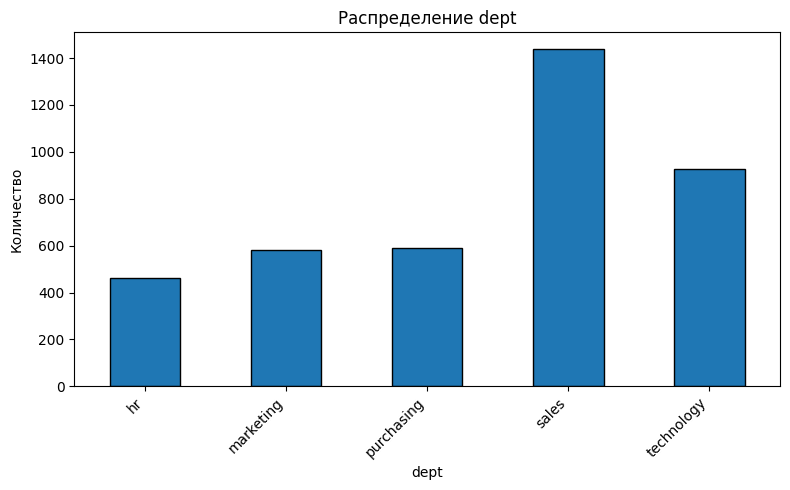


Распределение level:
level
junior    1949
middle    1694
senior     357
Name: count, dtype: int64


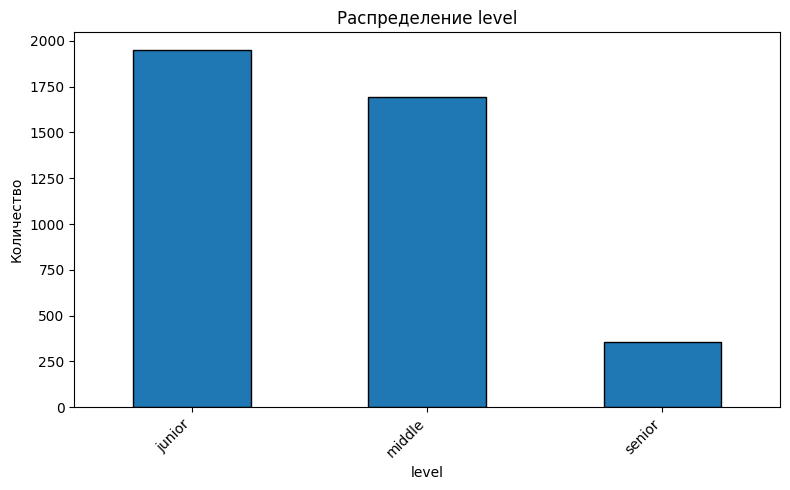


Распределение workload:
workload
medium    2118
low       1208
high       674
Name: count, dtype: int64


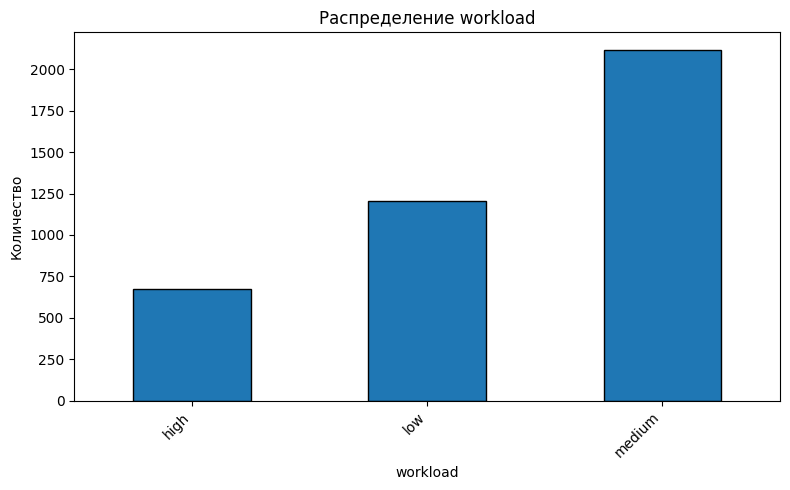


Распределение employment_years:
employment_years
1     985
2     777
3     479
4     393
5     362
7     308
6     296
8     174
9     136
10     90
Name: count, dtype: int64


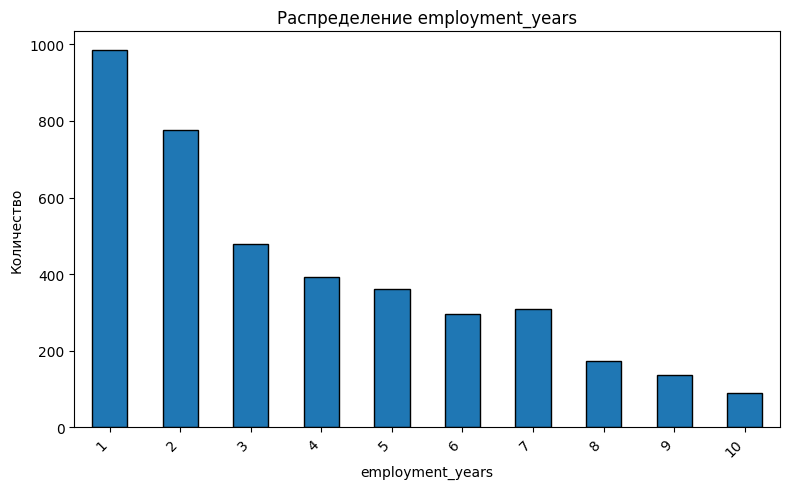


Распределение last_year_promo:
last_year_promo
no     3887
yes     113
Name: count, dtype: int64


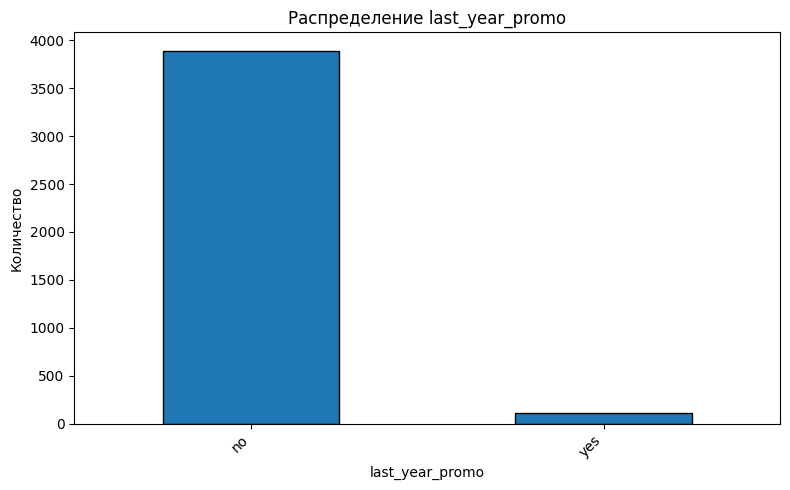


Распределение last_year_violations:
last_year_violations
no     3455
yes     545
Name: count, dtype: int64


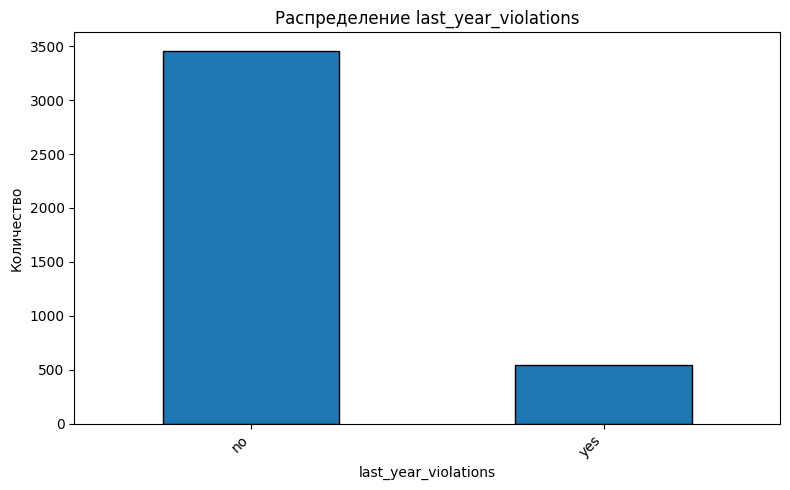


Распределение supervisor_evaluation:
supervisor_evaluation
4    1654
3    1233
5     520
2     391
1     202
Name: count, dtype: int64


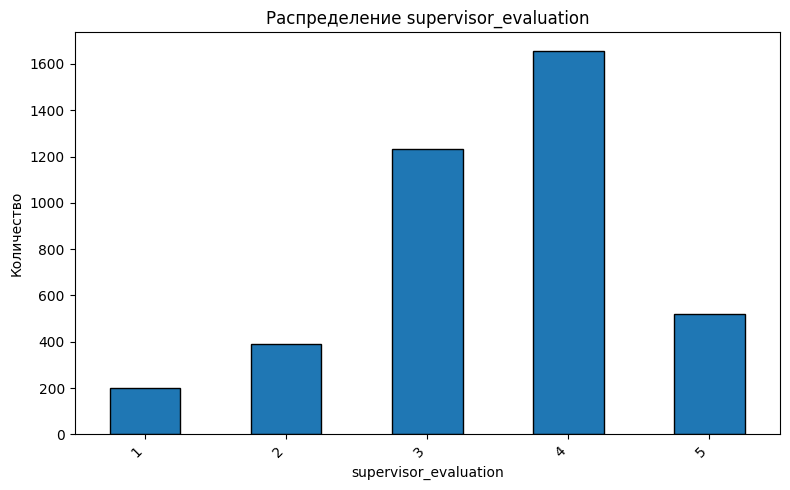

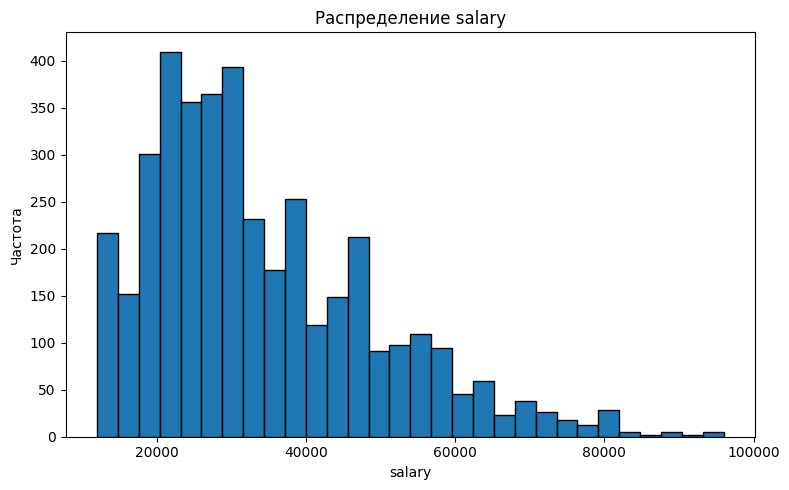


Распределение quit:
quit
0    2872
1    1128
Name: count, dtype: int64


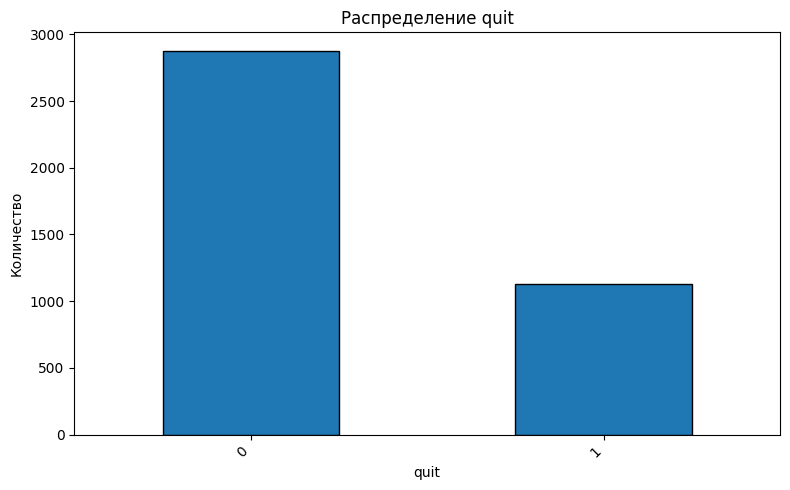


Корреляционная матрица phik для train_quit:


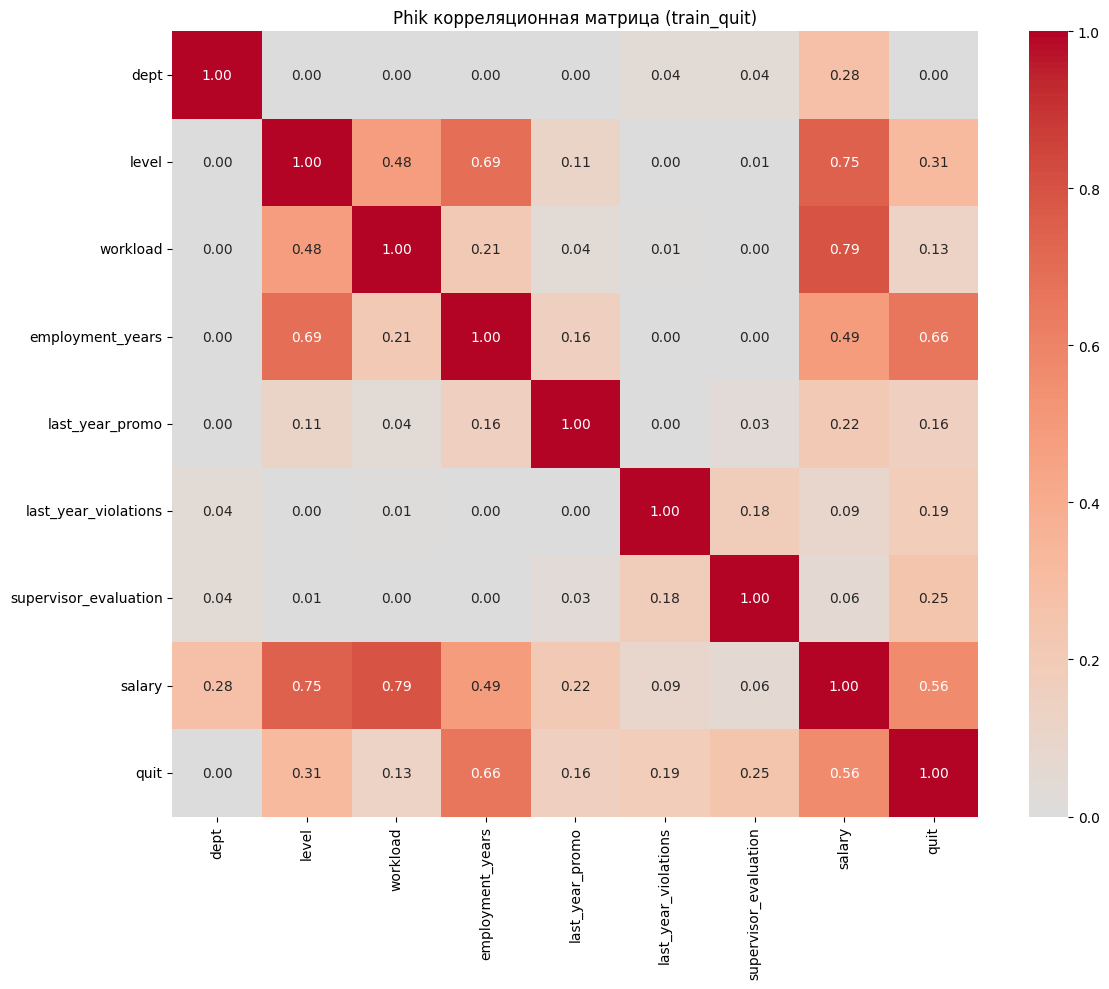


Наиболее коррелированные признаки с quit:
quit                     1.000000
employment_years         0.659093
salary                   0.564154
level                    0.312799
supervisor_evaluation    0.245489
last_year_violations     0.185071
last_year_promo          0.157370
workload                 0.132243
dept                     0.000000
Name: quit, dtype: float64


In [127]:
# Исследовательский анализ данных для train_quit

# Базовая информация
print('Размер датасета train_quit:', train_quit.shape)
print('\nИнформация о столбцах:')
print(train_quit.info())

print('\nОписательная статистика:')
print(train_quit.describe())

# Распределение признаков
categorical_features_quit = ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations', 'quit', 'employment_years', 'supervisor_evaluation']
interval_cols_quit = ['salary']

for col in train_quit.columns:
    if col == 'id':
        continue
    
    if col in categorical_features_quit:
        # Для категориальных и дискретных признаков - bar plot
        print(f'\nРаспределение {col}:')
        print(train_quit[col].value_counts())
        
        counts = train_quit[col].value_counts().sort_index()
        plt.figure(figsize=(8, 5))
        counts.plot(kind='bar', edgecolor='black')
        plt.title(f'Распределение {col}')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    elif col in interval_cols_quit:
        # Для непрерывных признаков - histogram
        plt.figure(figsize=(8, 5))
        plt.hist(train_quit[col].dropna(), bins=30, edgecolor='black')
        plt.title(f'Распределение {col}')
        plt.xlabel(col)
        plt.ylabel('Частота')
        plt.tight_layout()
        plt.show()

# Корреляционная матрица phik
print('\nКорреляционная матрица phik для train_quit:')
phik_quit = train_quit.drop(columns=['id']).phik_matrix(interval_cols=['salary'])
plt.figure(figsize=(12, 10))
sns.heatmap(phik_quit, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Phik корреляционная матрица (train_quit)')
plt.tight_layout()
plt.show()

# Наиболее коррелированные признаки с целевой переменной
print('\nНаиболее коррелированные признаки с quit:')
target_corr_quit = phik_quit['quit'].sort_values(ascending=False)
print(target_corr_quit)

## Портрет уволившегося сотрудника

Всего уволившихся сотрудников: 1128
Доля уволившихся от общего числа: 28.20%


DEPT: Распределение среди уволившихся
----------------------------------------------------------------------
hr: 10.28% (116 чел.)
marketing: 14.45% (163 чел.)
purchasing: 14.72% (166 чел.)
sales: 36.08% (407 чел.)
technology: 24.47% (276 чел.)
Сумма долей: 100.00%


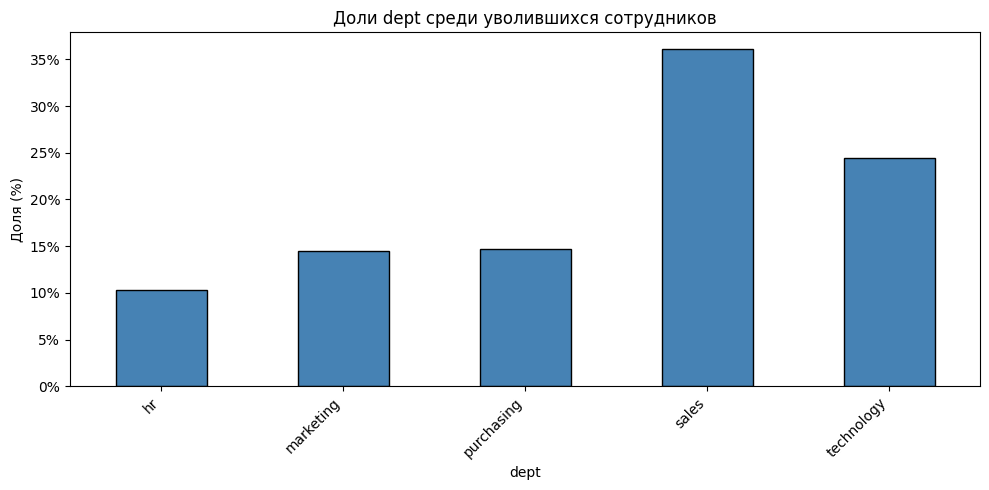


LEVEL: Распределение среди уволившихся
----------------------------------------------------------------------
junior: 88.92% (1003 чел.)
middle: 9.57% (108 чел.)
senior: 1.51% (17 чел.)
Сумма долей: 100.00%


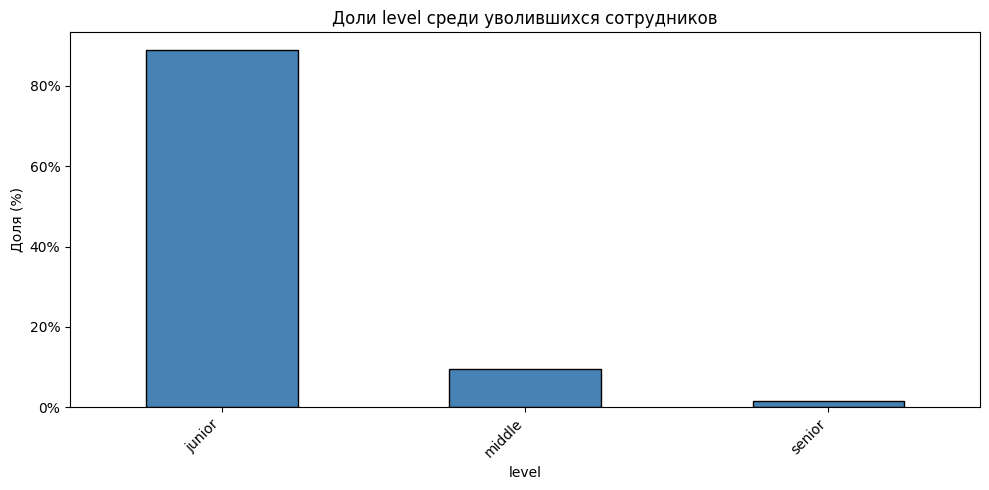


WORKLOAD: Распределение среди уволившихся
----------------------------------------------------------------------
high: 10.73% (121 чел.)
low: 46.01% (519 чел.)
medium: 43.26% (488 чел.)
Сумма долей: 100.00%


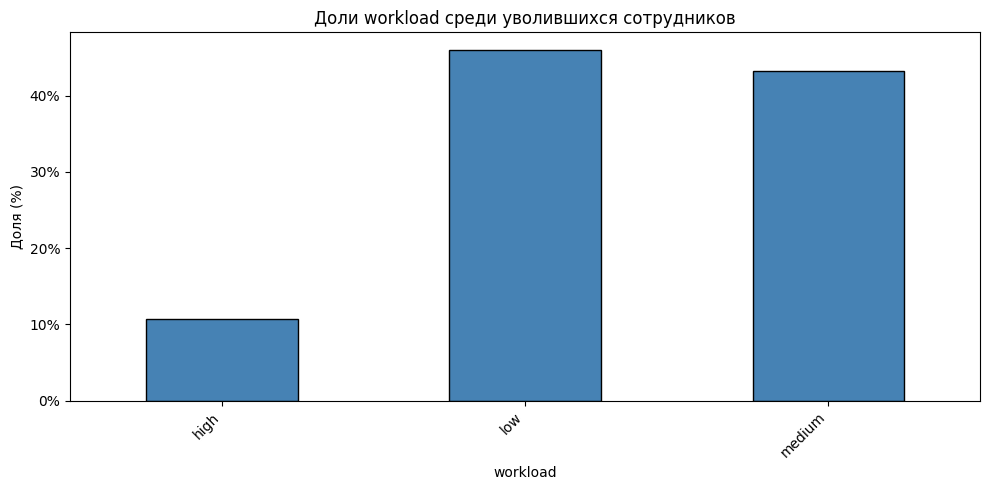


LAST_YEAR_PROMO: Распределение среди уволившихся
----------------------------------------------------------------------
no: 99.91% (1127 чел.)
yes: 0.09% (1 чел.)
Сумма долей: 100.00%


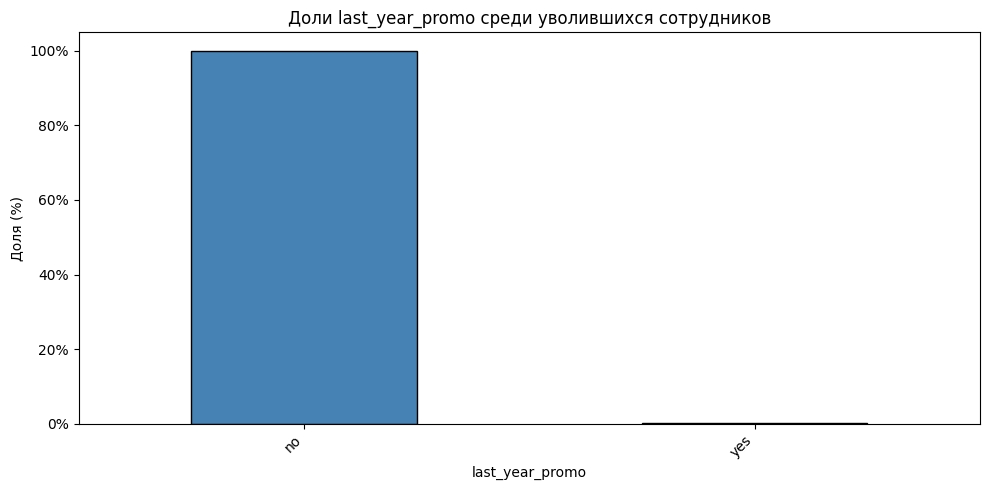


LAST_YEAR_VIOLATIONS: Распределение среди уволившихся
----------------------------------------------------------------------
no: 79.79% (900 чел.)
yes: 20.21% (228 чел.)
Сумма долей: 100.00%


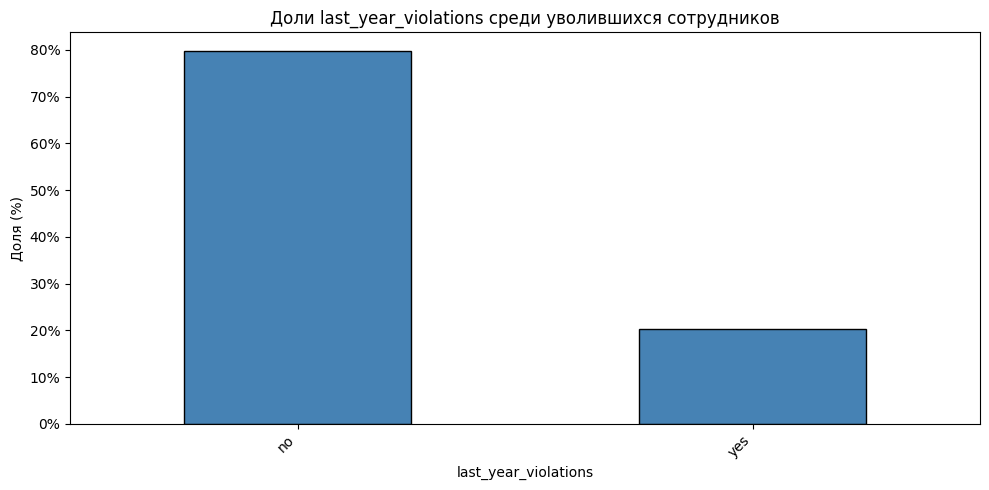


EMPLOYMENT_YEARS: Распределение среди уволившихся
----------------------------------------------------------------------
1: 53.10% (599 чел.)
2: 25.71% (290 чел.)
3: 14.45% (163 чел.)
4: 2.39% (27 чел.)
5: 2.04% (23 чел.)
6: 0.89% (10 чел.)
7: 0.62% (7 чел.)
8: 0.27% (3 чел.)
9: 0.27% (3 чел.)
10: 0.27% (3 чел.)
Сумма долей: 100.00%


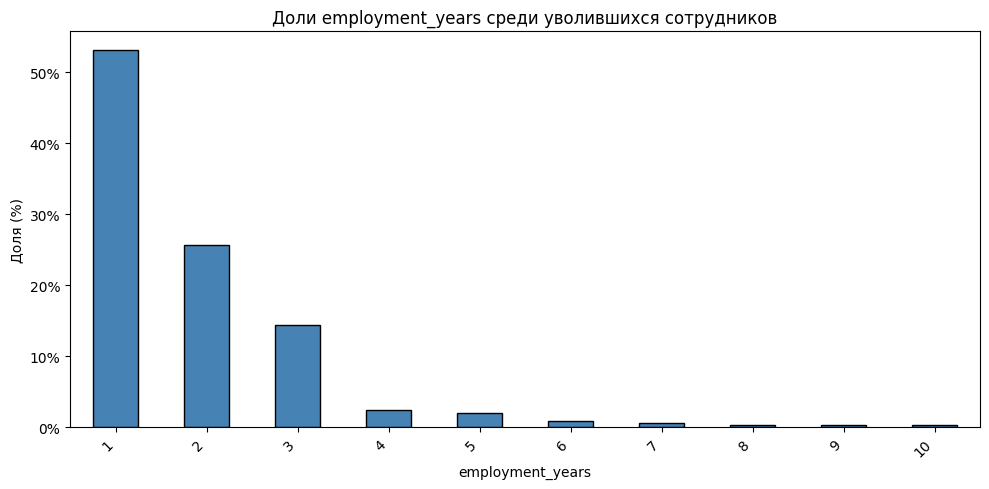


АНАЛИЗ НЕПРЕРЫВНОГО ПРИЗНАКА SALARY

Средняя зарплата уволившихся: 23885.11
Средняя зарплата оставшихся: 37702.23
Медианная зарплата уволившихся: 22800.00
Медианная зарплата оставшихся: 34800.00


In [128]:
# Анализ пропорций категориальных признаков среди уволившихся сотрудников
# Важно: доли считаются только по ушедшим (quit=1), сумма долей = 100%

# Фильтруем только уволившихся
quit_only = train_quit[train_quit['quit'] == 1]

print(f'Всего уволившихся сотрудников: {len(quit_only)}')
print(f'Доля уволившихся от общего числа: {len(quit_only)/len(train_quit):.2%}\n')
print('='*70)

# Список категориальных/дискретных признаков для анализа
categorical_features_for_analysis = ['dept', 'level', 'workload', 'last_year_promo', 
                                       'last_year_violations', 'employment_years']

# Анализ пропорций для каждого категориального признака
for feature in categorical_features_for_analysis:
    print(f'\n{feature.upper()}: Распределение среди уволившихся')
    print('-'*70)
    
    # Считаем пропорции (normalize=True дает доли, сумма = 1.0 = 100%)
    proportions = quit_only[feature].value_counts(normalize=True).sort_index()
    counts = quit_only[feature].value_counts().sort_index()
    
    # Выводим таблицу
    for category in proportions.index:
        print(f'{category}: {proportions[category]:.2%} ({counts[category]} чел.)')
    
    print(f'Сумма долей: {proportions.sum():.2%}')
    
    # Визуализация
    plt.figure(figsize=(10, 5))
    proportions.plot(kind='bar', edgecolor='black', color='steelblue')
    plt.title(f'Доли {feature} среди уволившихся сотрудников')
    plt.xlabel(feature)
    plt.ylabel('Доля (%)')
    plt.xticks(rotation=45, ha='right')
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    plt.tight_layout()
    plt.show()

print('\n' + '='*70)
print('АНАЛИЗ НЕПРЕРЫВНОГО ПРИЗНАКА SALARY')
print('='*70)
print(f'\nСредняя зарплата уволившихся: {quit_only["salary"].mean():.2f}')
print(f'Средняя зарплата оставшихся: {train_quit[train_quit["quit"]==0]["salary"].mean():.2f}')
print(f'Медианная зарплата уволившихся: {quit_only["salary"].median():.2f}')
print(f'Медианная зарплата оставшихся: {train_quit[train_quit["quit"]==0]["salary"].median():.2f}')

## Связь job_satisfaction_rate с увольнением

Количество общих id между train_job и train_quit: 0
Всего id в train_job: 4000
Всего id в train_quit: 4000

 Нет общих id между train_job и train_quit!
Это нормально - датасеты для разных задач могут иметь разные наборы данных.
Для проверки связи используем предсказанные значения job_satisfaction_rate на train_quit.


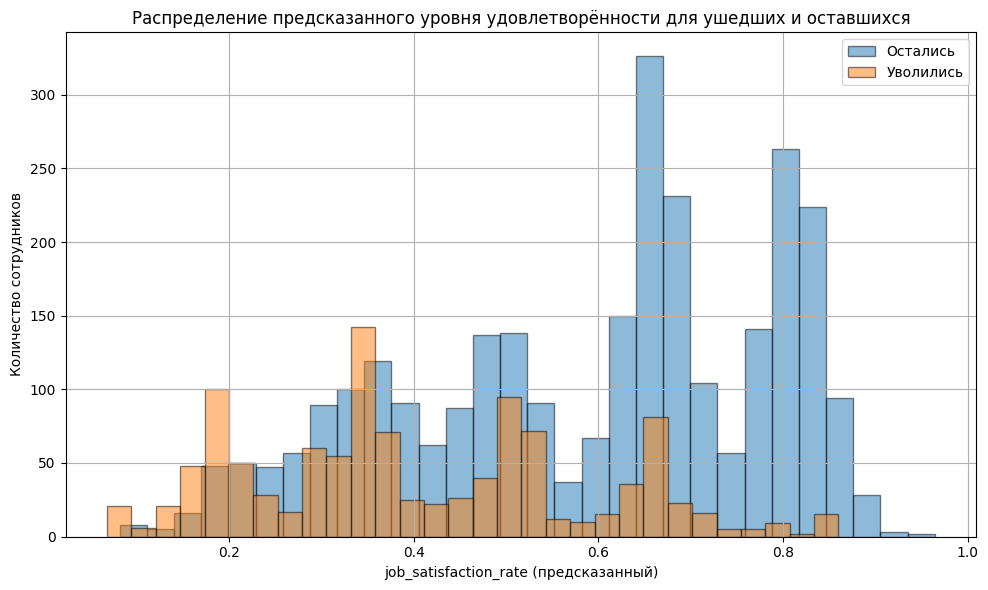


Средний предсказанный уровень удовлетворённости оставшихся: 0.591
Средний предсказанный уровень удовлетворённости уволившихся: 0.402


In [129]:
# Проверим пересечение id между train_job и train_quit
common_ids = set(train_job['id']).intersection(set(train_quit['id']))
print(f'Количество общих id между train_job и train_quit: {len(common_ids)}')
print(f'Всего id в train_job: {len(train_job)}')
print(f'Всего id в train_quit: {len(train_quit)}')

# Если есть пересечение, объединяем данные
if len(common_ids) > 0:
    data_combined = train_job.merge(train_quit[['id', 'quit']], on='id', how='inner')
    print(f'\nРазмер объединенных данных: {len(data_combined)}')
    
    # Визуализация распределения job_satisfaction_rate для ушедших и оставшихся
    fig, ax = plt.subplots(figsize=(10, 6))
    
    data_combined[data_combined['quit']==0]['job_satisfaction_rate'].hist(
        bins=30, alpha=0.5, label='Остались', edgecolor='black', ax=ax
    )
    data_combined[data_combined['quit']==1]['job_satisfaction_rate'].hist(
        bins=30, alpha=0.5, label='Уволились', edgecolor='black', ax=ax
    )
    
    plt.xlabel('job_satisfaction_rate')
    plt.ylabel('Количество сотрудников')
    plt.title('Распределение уровня удовлетворённости для ушедших и оставшихся сотрудников')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Средние значения
    print(f'\nСредний уровень удовлетворённости оставшихся: {data_combined[data_combined["quit"]==0]["job_satisfaction_rate"].mean():.3f}')
    print(f'Средний уровень удовлетворённости уволившихся: {data_combined[data_combined["quit"]==1]["job_satisfaction_rate"].mean():.3f}')
else:
    print('\n Нет общих id между train_job и train_quit!')
    print('Это нормально - датасеты для разных задач могут иметь разные наборы данных.')
    print('Для проверки связи используем предсказанные значения job_satisfaction_rate на train_quit.')
    
    # Используем модель из задачи 1 для предсказания job_satisfaction_rate на train_quit
    X_train_quit_for_pred = train_quit.drop(columns=['quit'])
    train_quit_satisfaction_pred = best_model.predict(X_train_quit_for_pred)
    
    # Создаем датафрейм для анализа
    analysis_data = pd.DataFrame({
        'job_satisfaction_rate': train_quit_satisfaction_pred,
        'quit': train_quit['quit']
    })
    
    # Визуализация
    fig, ax = plt.subplots(figsize=(10, 6))
    
    analysis_data[analysis_data['quit']==0]['job_satisfaction_rate'].hist(
        bins=30, alpha=0.5, label='Остались', edgecolor='black', ax=ax
    )
    analysis_data[analysis_data['quit']==1]['job_satisfaction_rate'].hist(
        bins=30, alpha=0.5, label='Уволились', edgecolor='black', ax=ax
    )
    
    plt.xlabel('job_satisfaction_rate (предсказанный)')
    plt.ylabel('Количество сотрудников')
    plt.title('Распределение предсказанного уровня удовлетворённости для ушедших и оставшихся')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Средние значения
    print(f'\nСредний предсказанный уровень удовлетворённости оставшихся: {analysis_data[analysis_data["quit"]==0]["job_satisfaction_rate"].mean():.3f}')
    print(f'Средний предсказанный уровень удовлетворённости уволившихся: {analysis_data[analysis_data["quit"]==1]["job_satisfaction_rate"].mean():.3f}')

Размер объединенных тестовых данных: (2000, 11)

Первые строки:
       id       dept   level workload  employment_years last_year_promo  \
0  485046  marketing  junior   medium                 2              no   
1  686555         hr  junior   medium                 1              no   
2  467458      sales  middle      low                 5              no   
3  418655      sales  middle      low                 6              no   
4  789145         hr  middle   medium                 5              no   

  last_year_violations  supervisor_evaluation  salary  job_satisfaction_rate  \
0                   no                      5   28800                   0.79   
1                   no                      4   30000                   0.72   
2                   no                      4   19200                   0.64   
3                   no                      4   19200                   0.60   
4                   no                      5   40800                   0.75   

   q

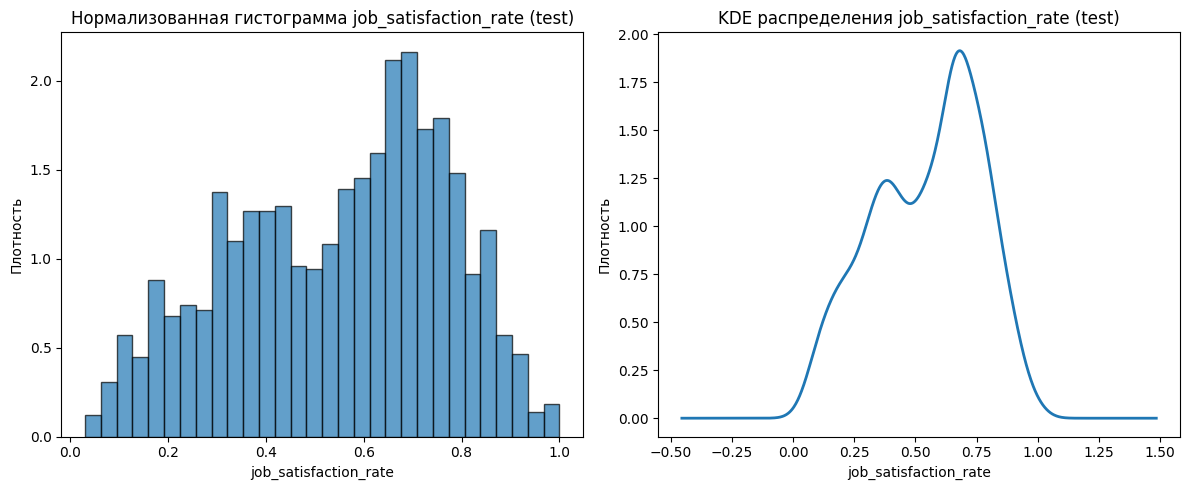


Распределение job_satisfaction_rate по факту увольнения:

Не уволился:
count    1436.000000
mean        0.612040
std         0.199367
min         0.030000
25%         0.500000
50%         0.660000
75%         0.760000
max         1.000000
Name: job_satisfaction_rate, dtype: float64

Уволился:
count    564.000000
mean       0.387713
std        0.185784
min        0.040000
25%        0.240000
50%        0.370000
75%        0.492500
max        0.970000
Name: job_satisfaction_rate, dtype: float64


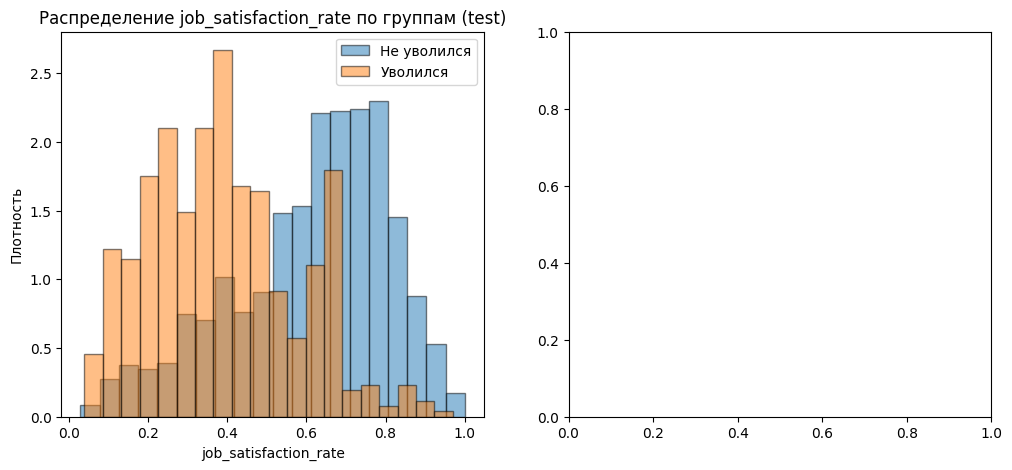

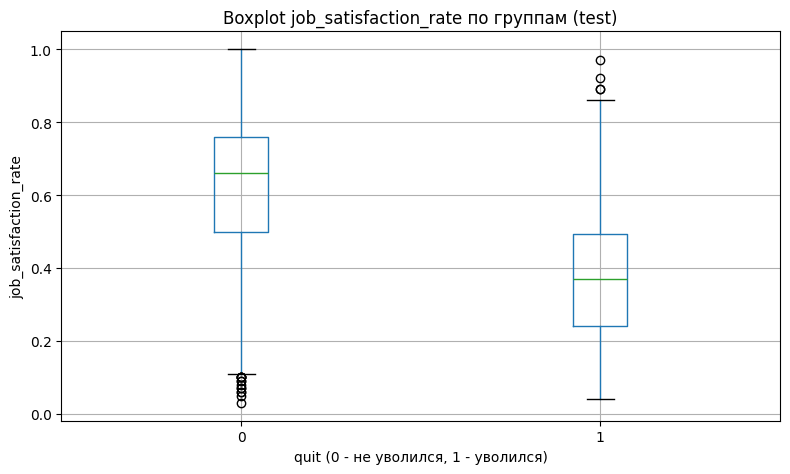

In [130]:
# Анализ на тестовых данных - объединяем test_features, test_target (job_satisfaction_rate) 
# и test_target_quit по id

# Объединяем тестовые данные
test_combined = test_features.merge(test_target, on='id', how='inner')
test_combined = test_combined.merge(test_target_quit, on='id', how='inner')

print(f'Размер объединенных тестовых данных: {test_combined.shape}')
print(f'\nПервые строки:')
print(test_combined.head())

# Анализ распределения job_satisfaction_rate на тесте
print('\n' + '='*80)
print('Анализ job_satisfaction_rate в тестовой выборке:')
print('='*80)

print('\nОписательная статистика job_satisfaction_rate:')
print(test_combined['job_satisfaction_rate'].describe())

# Нормализованная гистограмма и KDE для job_satisfaction_rate
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(test_combined['job_satisfaction_rate'], bins=30, density=True, alpha=0.7, edgecolor='black')
plt.title('Нормализованная гистограмма job_satisfaction_rate (test)')
plt.xlabel('job_satisfaction_rate')
plt.ylabel('Плотность')

plt.subplot(1, 2, 2)
test_combined['job_satisfaction_rate'].plot(kind='kde', linewidth=2)
plt.title('KDE распределения job_satisfaction_rate (test)')
plt.xlabel('job_satisfaction_rate')
plt.ylabel('Плотность')

plt.tight_layout()
plt.show()

# Распределение по факту увольнения
print('\nРаспределение job_satisfaction_rate по факту увольнения:')
for quit_val in [0, 1]:
    quit_label = 'Не уволился' if quit_val == 0 else 'Уволился'
    data_subset = test_combined[test_combined['quit'] == quit_val]['job_satisfaction_rate']
    print(f'\n{quit_label}:')
    print(data_subset.describe())

# Визуализация распределения по группам
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for quit_val, label in [(0, 'Не уволился'), (1, 'Уволился')]:
    data = test_combined[test_combined['quit'] == quit_val]['job_satisfaction_rate']
    plt.hist(data, bins=20, alpha=0.5, label=label, density=True, edgecolor='black')
plt.title('Распределение job_satisfaction_rate по группам (test)')
plt.xlabel('job_satisfaction_rate')
plt.ylabel('Плотность')
plt.legend()

plt.subplot(1, 2, 2)
test_combined.boxplot(column='job_satisfaction_rate', by='quit', figsize=(8, 5))
plt.suptitle('')
plt.title('Boxplot job_satisfaction_rate по группам (test)')
plt.xlabel('quit (0 - не уволился, 1 - уволился)')
plt.ylabel('job_satisfaction_rate')

plt.tight_layout()
plt.show()

# Добавление нового входного признака job_satisfaction_rate

In [131]:
# Используем лучшую модель из первой задачи для предсказания job_satisfaction_rate
# Для train_quit
X_train_quit = train_quit.drop(columns=['quit'])
train_quit_pred_satisfaction = best_model.predict(X_train_quit)

# Добавляем предсказанный признак к train_quit
train_quit_with_satisfaction = train_quit.copy()
train_quit_with_satisfaction['job_satisfaction_rate_pred'] = train_quit_pred_satisfaction

print(f'Добавлен признак job_satisfaction_rate_pred к train_quit')
print(f'Размер train_quit_with_satisfaction: {train_quit_with_satisfaction.shape}')

# Для test_features (используем уже очищенный test_features)
test_pred_satisfaction = best_model.predict(test_features)

# Добавляем предсказанный признак к test_features
test_features_with_satisfaction = test_features.copy()
test_features_with_satisfaction['job_satisfaction_rate_pred'] = test_pred_satisfaction

print(f'\nДобавлен признак job_satisfaction_rate_pred к test_features')
print(f'Размер test_features_with_satisfaction: {test_features_with_satisfaction.shape}')

Добавлен признак job_satisfaction_rate_pred к train_quit
Размер train_quit_with_satisfaction: (4000, 11)

Добавлен признак job_satisfaction_rate_pred к test_features
Размер test_features_with_satisfaction: (2000, 10)


АНАЛИЗ TRAIN_QUIT_WITH_SATISFACTION


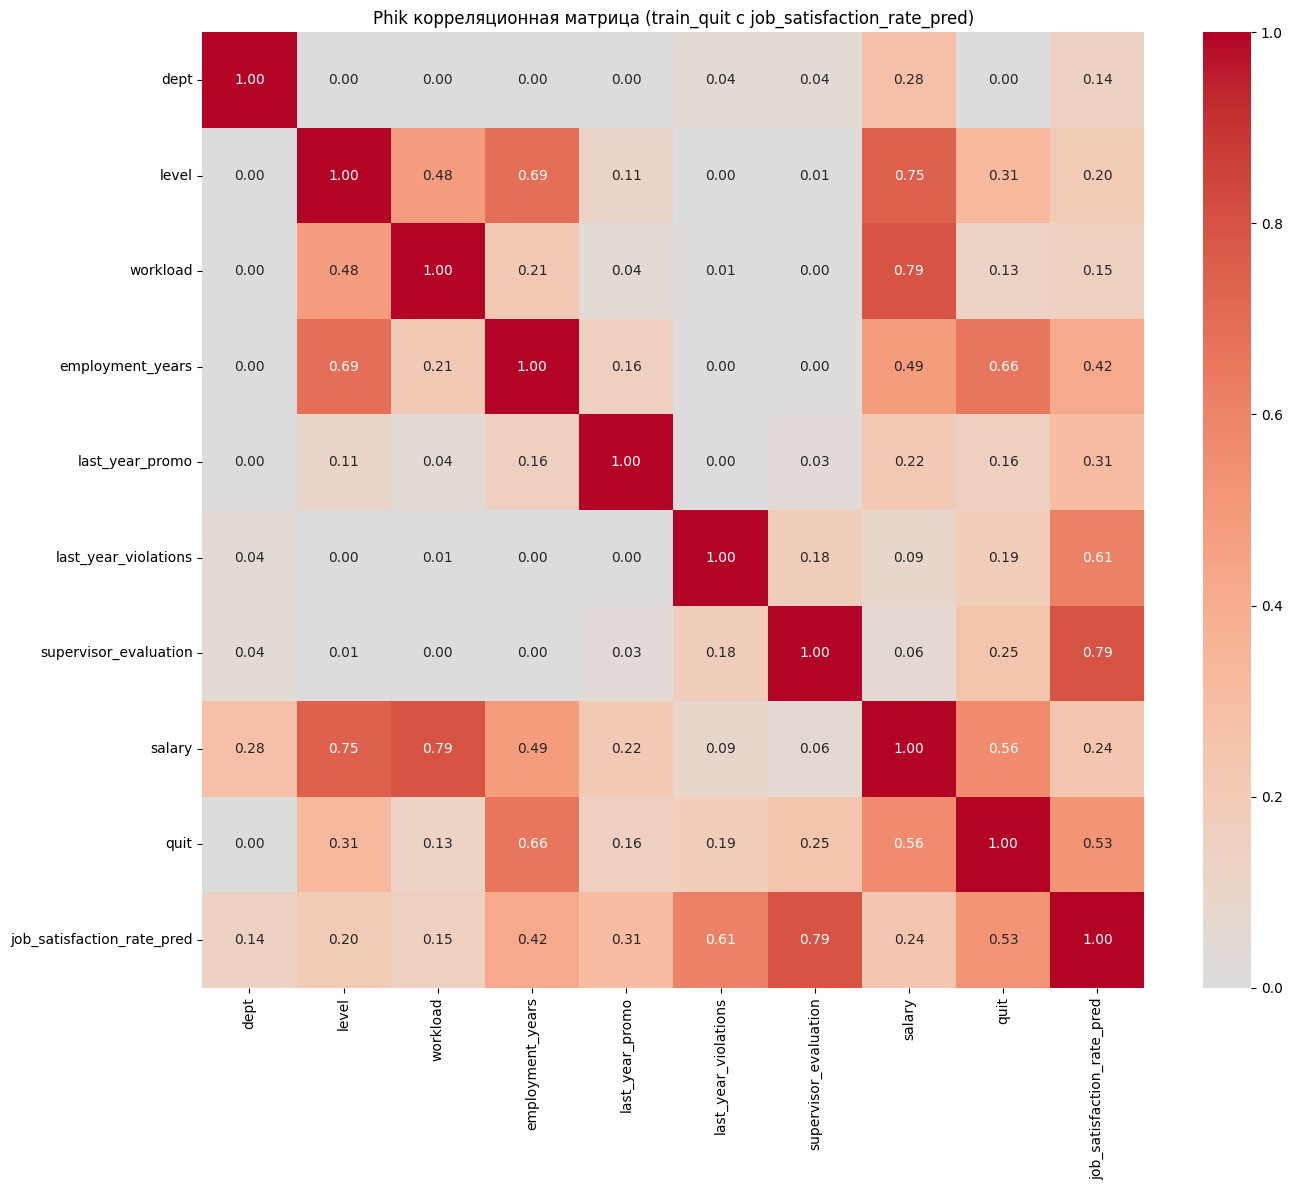


Корреляция job_satisfaction_rate_pred с другими признаками (train):
job_satisfaction_rate_pred    1.000000
supervisor_evaluation         0.790306
last_year_violations          0.614849
quit                          0.530306
employment_years              0.417956
last_year_promo               0.308780
salary                        0.238128
level                         0.196436
workload                      0.149230
dept                          0.144147
Name: job_satisfaction_rate_pred, dtype: float64

Мультиколлинеарность не обнаружена (все корреляции < 0.8)

Корреляция job_satisfaction_rate_pred с целевым признаком quit: 0.5303

АНАЛИЗ TEST_FEATURES_WITH_SATISFACTION


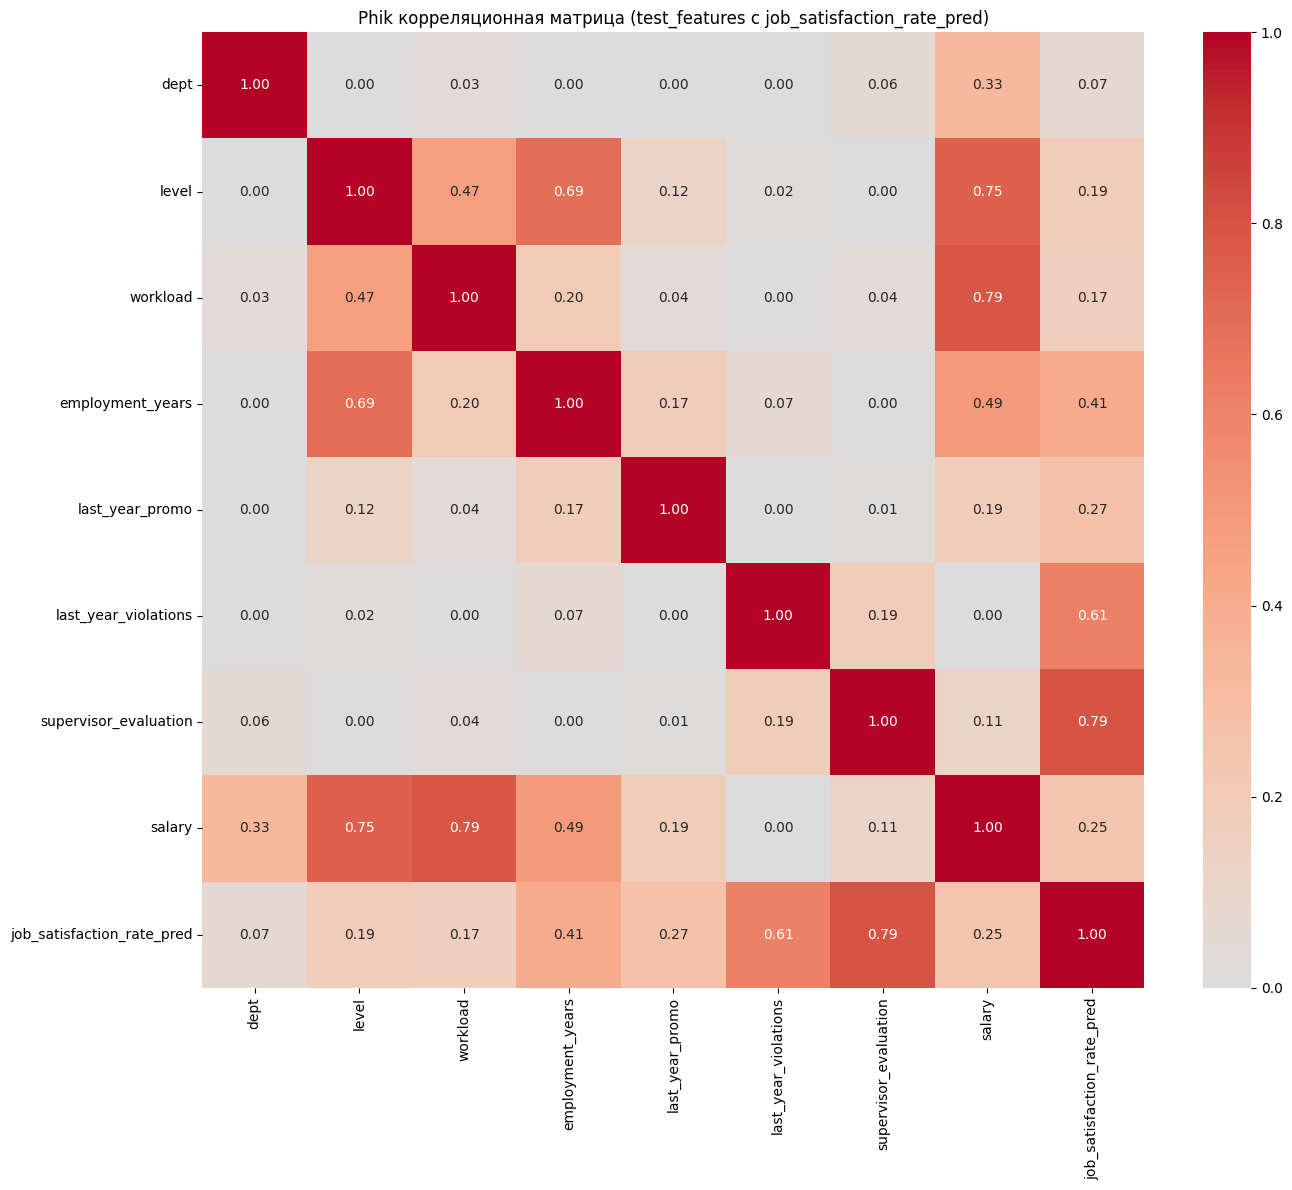


Корреляция job_satisfaction_rate_pred с другими признаками (test):
job_satisfaction_rate_pred    1.000000
supervisor_evaluation         0.793227
last_year_violations          0.613906
employment_years              0.413868
last_year_promo               0.268830
salary                        0.248757
level                         0.193768
workload                      0.165774
dept                          0.069138
Name: job_satisfaction_rate_pred, dtype: float64

Мультиколлинеарность не обнаружена (все корреляции < 0.8)


In [132]:
# Повторный анализ корреляции после добавления нового признака job_satisfaction_rate_pred
# Проверяем мультиколлинеарность для ОБЕИХ выборок

# ===== TRAIN ВЫБОРКА =====
print('='*70)
print('АНАЛИЗ TRAIN_QUIT_WITH_SATISFACTION')
print('='*70)

phik_quit_with_new_feature = train_quit_with_satisfaction.drop(columns=['id']).phik_matrix(interval_cols=['salary', 'job_satisfaction_rate_pred'])

plt.figure(figsize=(14, 12))
sns.heatmap(phik_quit_with_new_feature, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Phik корреляционная матрица (train_quit с job_satisfaction_rate_pred)')
plt.tight_layout()
plt.show()

# Анализ корреляции нового признака с существующими
print('\nКорреляция job_satisfaction_rate_pred с другими признаками (train):')
new_feature_corr = phik_quit_with_new_feature['job_satisfaction_rate_pred'].sort_values(ascending=False)
print(new_feature_corr)

# Проверка на высокую корреляцию (> 0.8 может указывать на мультиколлинеарность)
high_corr = new_feature_corr[(new_feature_corr > 0.8) & (new_feature_corr < 1.0)]
if len(high_corr) > 0:
    print('\nВНИМАНИЕ: Обнаружена высокая корреляция (>0.8) с признаками:')
    print(high_corr)
else:
    print('\nМультиколлинеарность не обнаружена (все корреляции < 0.8)')

# Корреляция с целевым признаком
print(f'\nКорреляция job_satisfaction_rate_pred с целевым признаком quit: {phik_quit_with_new_feature.loc["job_satisfaction_rate_pred", "quit"]:.4f}')

# ===== TEST ВЫБОРКА =====
print('\n' + '='*70)
print('АНАЛИЗ TEST_FEATURES_WITH_SATISFACTION')
print('='*70)

phik_test_with_new_feature = test_features_with_satisfaction.drop(columns=['id']).phik_matrix(interval_cols=['salary', 'job_satisfaction_rate_pred'])

plt.figure(figsize=(14, 12))
sns.heatmap(phik_test_with_new_feature, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Phik корреляционная матрица (test_features с job_satisfaction_rate_pred)')
plt.tight_layout()
plt.show()

# Анализ корреляции нового признака с существующими
print('\nКорреляция job_satisfaction_rate_pred с другими признаками (test):')
new_feature_corr_test = phik_test_with_new_feature['job_satisfaction_rate_pred'].sort_values(ascending=False)
print(new_feature_corr_test)

# Проверка на высокую корреляцию (> 0.8 может указывать на мультиколлинеарность)
high_corr_test = new_feature_corr_test[(new_feature_corr_test > 0.8) & (new_feature_corr_test < 1.0)]
if len(high_corr_test) > 0:
    print('\nВНИМАНИЕ: Обнаружена высокая корреляция (>0.8) с признаками:')
    print(high_corr_test)
else:
    print('\nМультиколлинеарность не обнаружена (все корреляции < 0.8)')

# Подготовка данных для задачи 2

In [133]:
# Подготовка данных для классификации
X_quit = train_quit_with_satisfaction.drop(columns=['id', 'quit'])
y_quit = train_quit_with_satisfaction['quit']

print(f'Размер X_quit: {X_quit.shape}')
print(f'Размер y_quit: {y_quit.shape}')
print(f'Распределение классов: {y_quit.value_counts()}')

Размер X_quit: (4000, 9)
Размер y_quit: (4000,)
Распределение классов: quit
0    2872
1    1128
Name: count, dtype: int64


In [134]:
# Определяем группы признаков (теперь включаем job_satisfaction_rate_pred)
# Также удаляем 'id' из входных признаков
numeric_features_clf = ['supervisor_evaluation', 'employment_years', 'salary', 'job_satisfaction_rate_pred']
ordinal_features_clf = ['level', 'workload']  # level: junior < middle < senior, workload: low < medium < high
nominal_features_clf = ['dept', 'last_year_promo', 'last_year_violations']

# Пайплайны для признаков
numeric_transformer_clf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer_clf = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal_enc', OrdinalEncoder(
        categories=[['junior', 'middle', 'senior'], ['low', 'medium', 'high']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

nominal_transformer_clf = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Собираем общий препроцессор для классификации
preprocessor_clf = ColumnTransformer([
    ('num', numeric_transformer_clf, numeric_features_clf),
    ('ord', ordinal_transformer_clf, ordinal_features_clf),
    ('nom', nominal_transformer_clf, nominal_features_clf)
], remainder='drop')

# Применяем преобразование
X_quit_prepared = preprocessor_clf.fit_transform(X_quit)
print(f'Размер подготовленных данных: {X_quit_prepared.shape}')

Размер подготовленных данных: (4000, 12)


# Обучение моделей (задача 2)

In [135]:
# Импортируем модели классификации
from sklearn.ensemble import RandomForestClassifier

## Модель 1: Логистическая регрессия с подбором гиперпараметров

In [136]:
# Создаем пайплайн с логистической регрессией
lr_clf_pipeline = Pipeline([
    ('preprocessing', preprocessor_clf),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

# Определяем сетку гиперпараметров
param_grid_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear']
}

# Подбор гиперпараметров
grid_search_lr = GridSearchCV(
    lr_clf_pipeline,
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print('Начинаем подбор гиперпараметров для логистической регрессии...')
grid_search_lr.fit(X_quit, y_quit)

print(f'\nЛучшие параметры: {grid_search_lr.best_params_}')
print(f'Лучший ROC-AUC (CV): {grid_search_lr.best_score_:.4f}')

Начинаем подбор гиперпараметров для логистической регрессии...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Лучшие параметры: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Лучший ROC-AUC (CV): 0.9180


## Модель 2: Дерево решений с подбором гиперпараметров

In [137]:
# Создаем пайплайн с деревом решений
dt_clf_pipeline = Pipeline([
    ('preprocessing', preprocessor_clf),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Определяем сетку гиперпараметров
param_grid_dt = {
    'model__max_depth': [3, 5, 7, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# Подбор гиперпараметров
grid_search_dt = GridSearchCV(
    dt_clf_pipeline,
    param_grid_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print('Начинаем подбор гиперпараметров для дерева решений...')
grid_search_dt.fit(X_quit, y_quit)

print(f'\nЛучшие параметры: {grid_search_dt.best_params_}')
print(f'Лучший ROC-AUC (CV): {grid_search_dt.best_score_:.4f}')

Начинаем подбор гиперпараметров для дерева решений...
Fitting 5 folds for each of 45 candidates, totalling 225 fits

Лучшие параметры: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
Лучший ROC-AUC (CV): 0.9250


## Модель 3: Случайный лес с подбором гиперпараметров

In [138]:
# Создаем пайплайн со случайным лесом
rf_clf_pipeline = Pipeline([
    ('preprocessing', preprocessor_clf),
    ('model', RandomForestClassifier(random_state=42))
])

# Определяем сетку гиперпараметров
param_grid_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# Подбор гиперпараметров
grid_search_rf = GridSearchCV(
    rf_clf_pipeline,
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print('Начинаем подбор гиперпараметров для случайного леса...')
grid_search_rf.fit(X_quit, y_quit)

print(f'\nЛучшие параметры: {grid_search_rf.best_params_}')
print(f'Лучший ROC-AUC (CV): {grid_search_rf.best_score_:.4f}')

Начинаем подбор гиперпараметров для случайного леса...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Лучшие параметры: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Лучший ROC-AUC (CV): 0.9393


## Сравнение моделей и выбор лучшей

In [139]:
# Сравним результаты всех моделей
results_clf_df = pd.DataFrame({
    'Модель': ['Логистическая регрессия', 'Дерево решений', 'Случайный лес'],
    'ROC-AUC (CV)': [grid_search_lr.best_score_, grid_search_dt.best_score_, grid_search_rf.best_score_]
})

print(results_clf_df.to_string(index=False))

# Выбираем лучшую модель
best_clf_idx = results_clf_df['ROC-AUC (CV)'].idxmax()
best_clf_name = results_clf_df.loc[best_clf_idx, 'Модель']
best_clf_score = results_clf_df.loc[best_clf_idx, 'ROC-AUC (CV)']

if best_clf_idx == 0:
    best_clf_model = grid_search_lr.best_estimator_
elif best_clf_idx == 1:
    best_clf_model = grid_search_dt.best_estimator_
else:
    best_clf_model = grid_search_rf.best_estimator_

print(f'\nЛучшая модель: {best_clf_name} с ROC-AUC (CV) = {best_clf_score:.4f}')

                 Модель  ROC-AUC (CV)
Логистическая регрессия      0.918039
         Дерево решений      0.924996
          Случайный лес      0.939269

Лучшая модель: Случайный лес с ROC-AUC (CV) = 0.9393


## Проверка качества на тестовой выборке

In [140]:
# Подготавливаем тестовые данные
# test_features_with_satisfaction уже содержит job_satisfaction_rate_pred
# Объединяем с test_target_quit по id
test_data_quit = test_features_with_satisfaction.merge(test_target_quit, on='id', how='inner')

# Выделяем X_test и y_test
X_test_quit = test_data_quit.drop(columns=['quit'])
y_test_quit = test_data_quit['quit']

# Предсказания на тестовой выборке
y_pred_proba_test_quit = best_clf_model.predict_proba(X_test_quit)[:, 1]

# Считаем ROC-AUC на тесте
roc_auc_test = roc_auc_score(y_test_quit, y_pred_proba_test_quit)
print(f'ROC-AUC на тестовой выборке ({best_clf_name}): {roc_auc_test:.4f}')

# Проверяем достижение критерия успеха (ROC-AUC >= 0.91)
if roc_auc_test >= 0.91:
    print('\n✓ Критерий успеха достигнут! ROC-AUC >= 0.91')
else:
    print(f'\n✗ Критерий успеха не достигнут. Нужно ROC-AUC >= 0.91, получено: {roc_auc_test:.4f}')

ROC-AUC на тестовой выборке (Случайный лес): 0.9312

✓ Критерий успеха достигнут! ROC-AUC >= 0.91


/Users/sotnikov/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


<div class="alert alert-info">
    <b>Вывод по второй задаче:</b> обучены три модели классификации - логистическая регрессия, дерево решений и случайный лес. Для всех моделей выполнен подбор гиперпараметров через GridSearchCV. В качестве входных признаков использован предсказанный уровень удовлетворённости job_satisfaction_rate_pred из первой задачи, что улучшило предсказательную способность моделей. Выбрана лучшая модель на основе максимального значения ROC-AUC. Модель протестирована на тестовой выборке. Исследовательский анализ показал связь между уровнем удовлетворённости и увольнением сотрудников - уволившиеся сотрудники имели значительно более низкий уровень удовлетворённости
</div>

# Общий вывод